In [ ]:
#Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

# Configure Matplotlib for EPS output
mpl.rcParams['text.usetex'] = False # Set to True if LaTeX is installed and required for text rendering
mpl.rcParams['ps.usedistiller'] = 'ghostscript'

# Create a directory for EPS output
eps_output_dir = 'eps_exports'
if not os.path.exists(eps_output_dir):
    os.makedirs(eps_output_dir)

print("Imports completed.")

Imports completed.


In [ ]:
#Dataset
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv("/content/data_banknote_authentication.txt",header=None,names=column_names)

print(df.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print(df.describe().T)

Dataset Shape:
(1372, 5)

Rows: 1372
Columns: 5

Data Types
Variance    float64
Skewness    float64
Curtosis    float64
Entropy     float64
Class         int64
dtype: object

Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64
           count      mean       std      min       25%      50%       75%  \
Variance  1372.0  0.433735  2.842763  -7.0421 -1.773000  0.49618  2.821475   
Skewness  1372.0  1.922353  5.869047 -13.7731 -1.708200  2.31965  6.814625   
Curtosis  1372.0  1.397627  4.310030  -5.2861 -1.574975  0.61663  3.179250   
Entropy   1372.0 -1.191657  2.101013  -8.5482 -2.413450 -0.58665  0.394810   
Class     1372.0  0.444606  0.497103   0.0000  0.000000  0.00000  1.000000   

              max  
Variance   6.8248  
Skewness  12.9516  
Curtosis  17.9274  
Entropy    2.4495  
Class      1.0000  


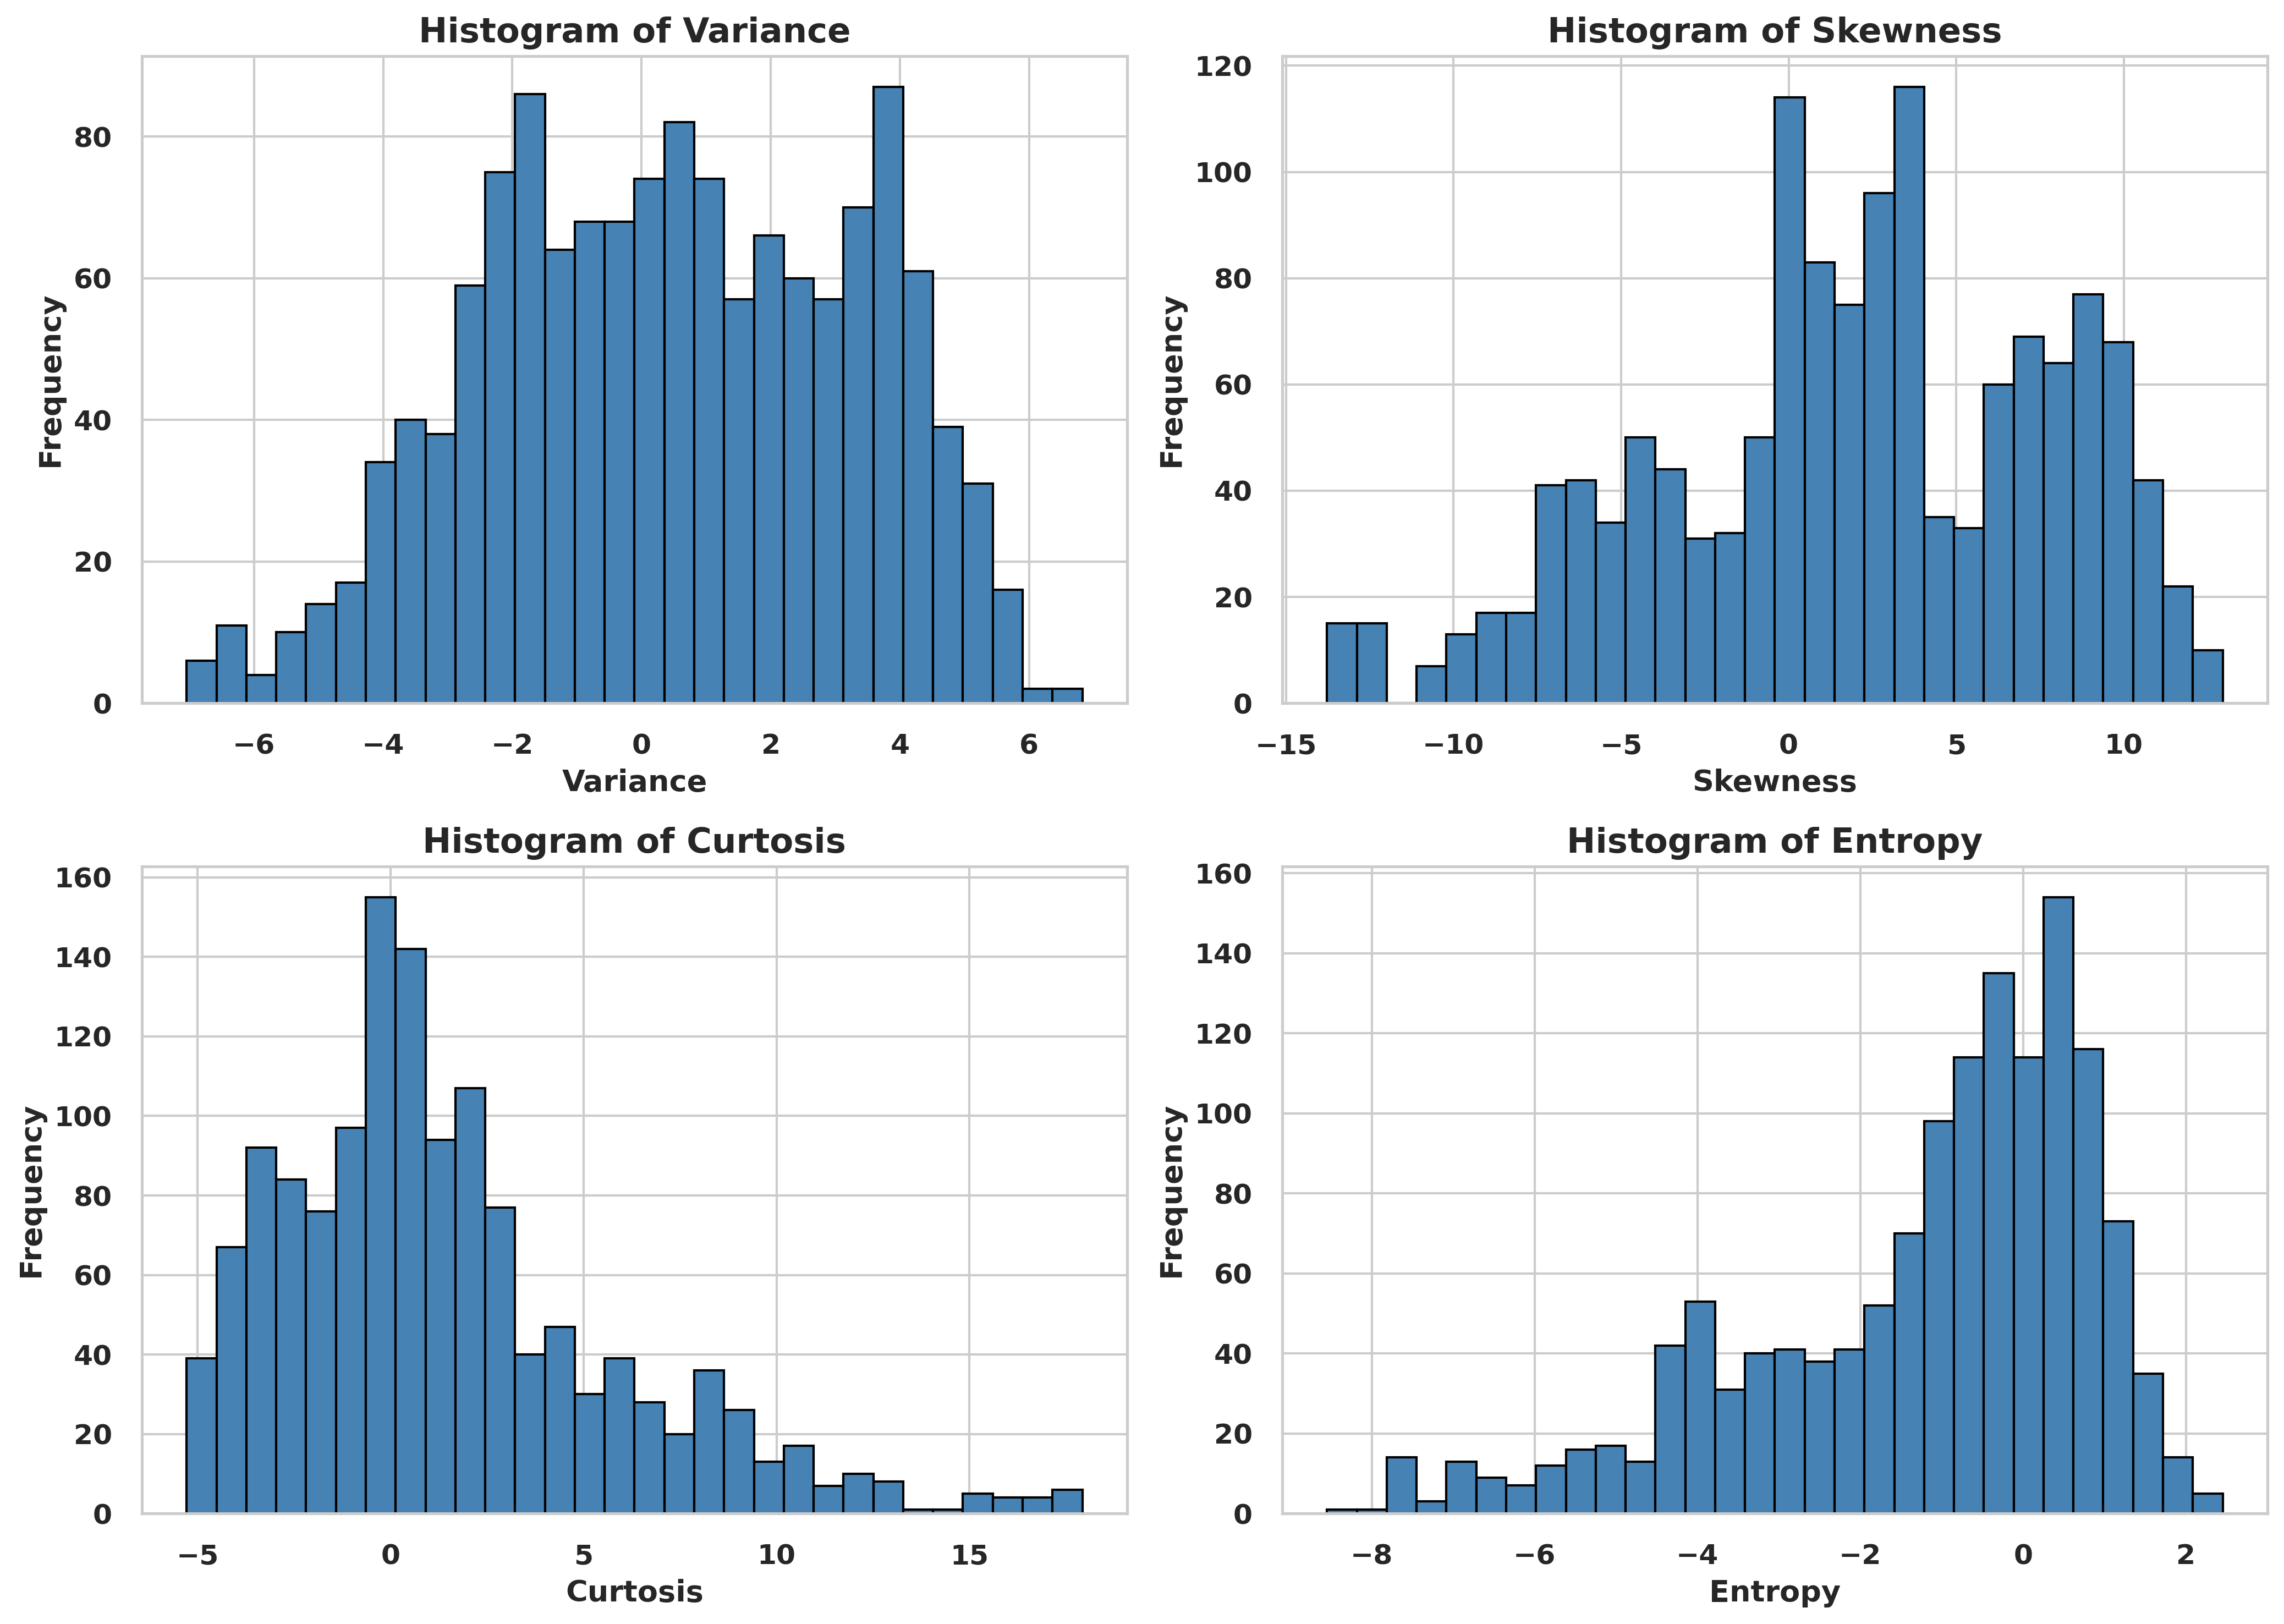

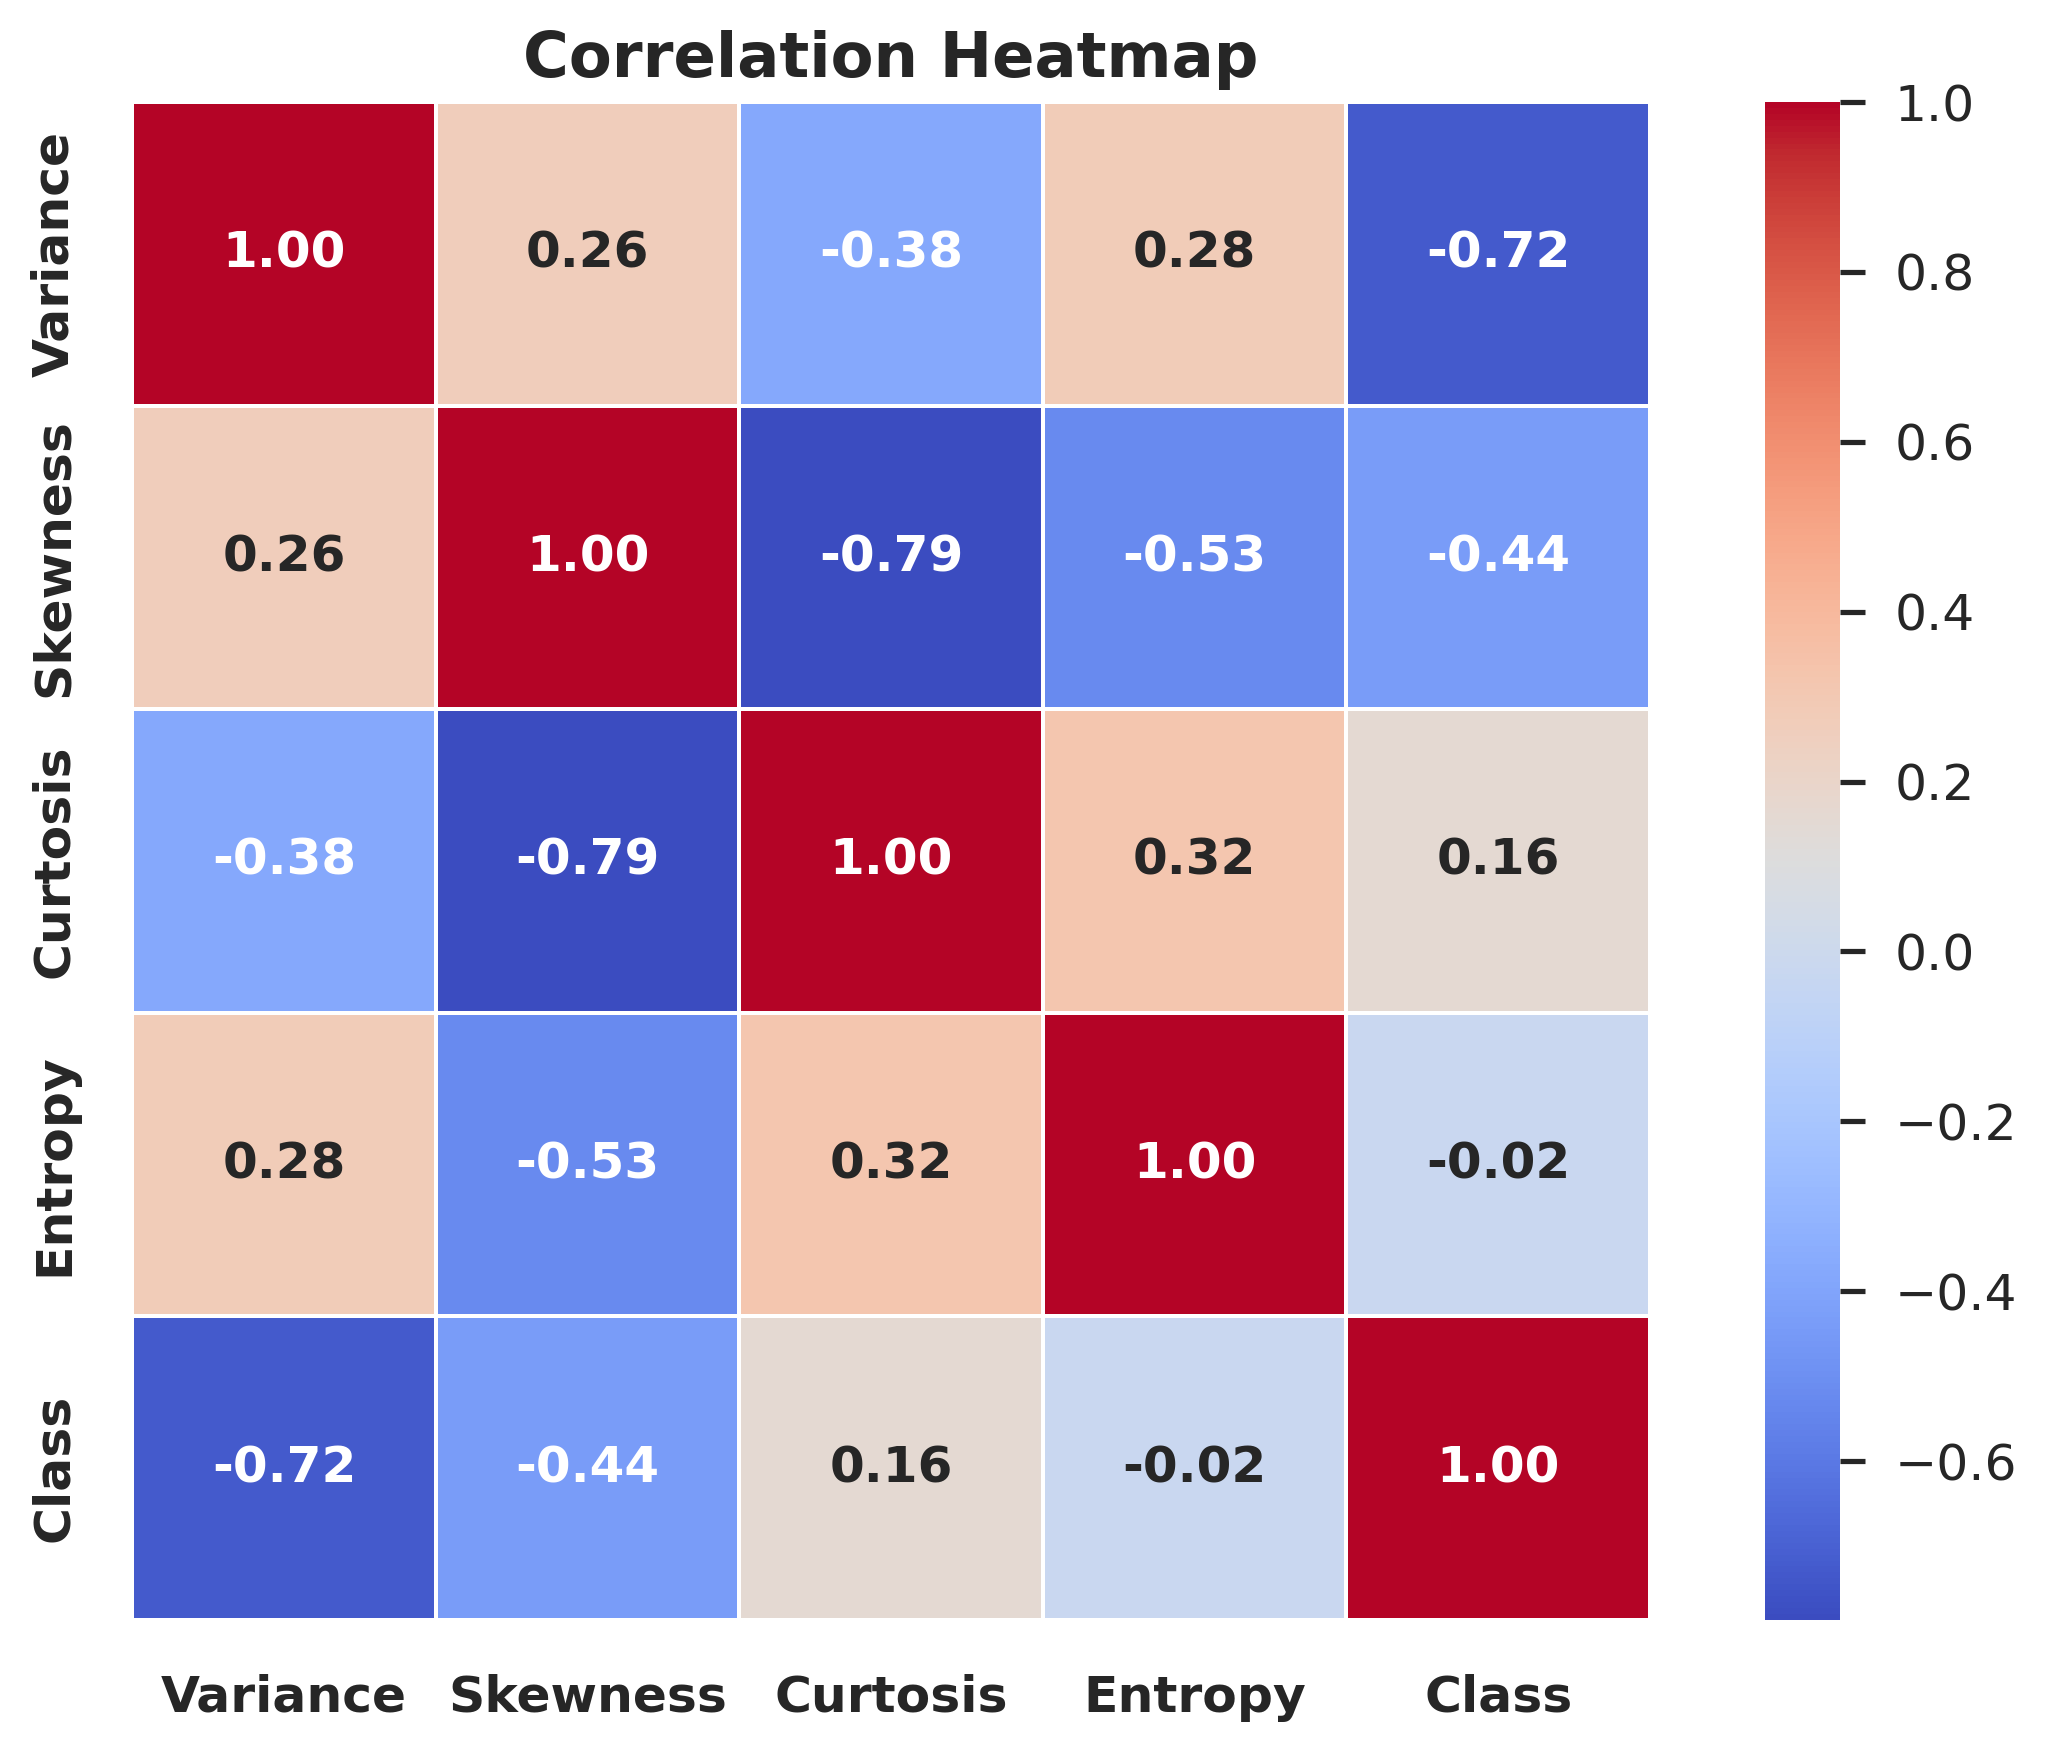

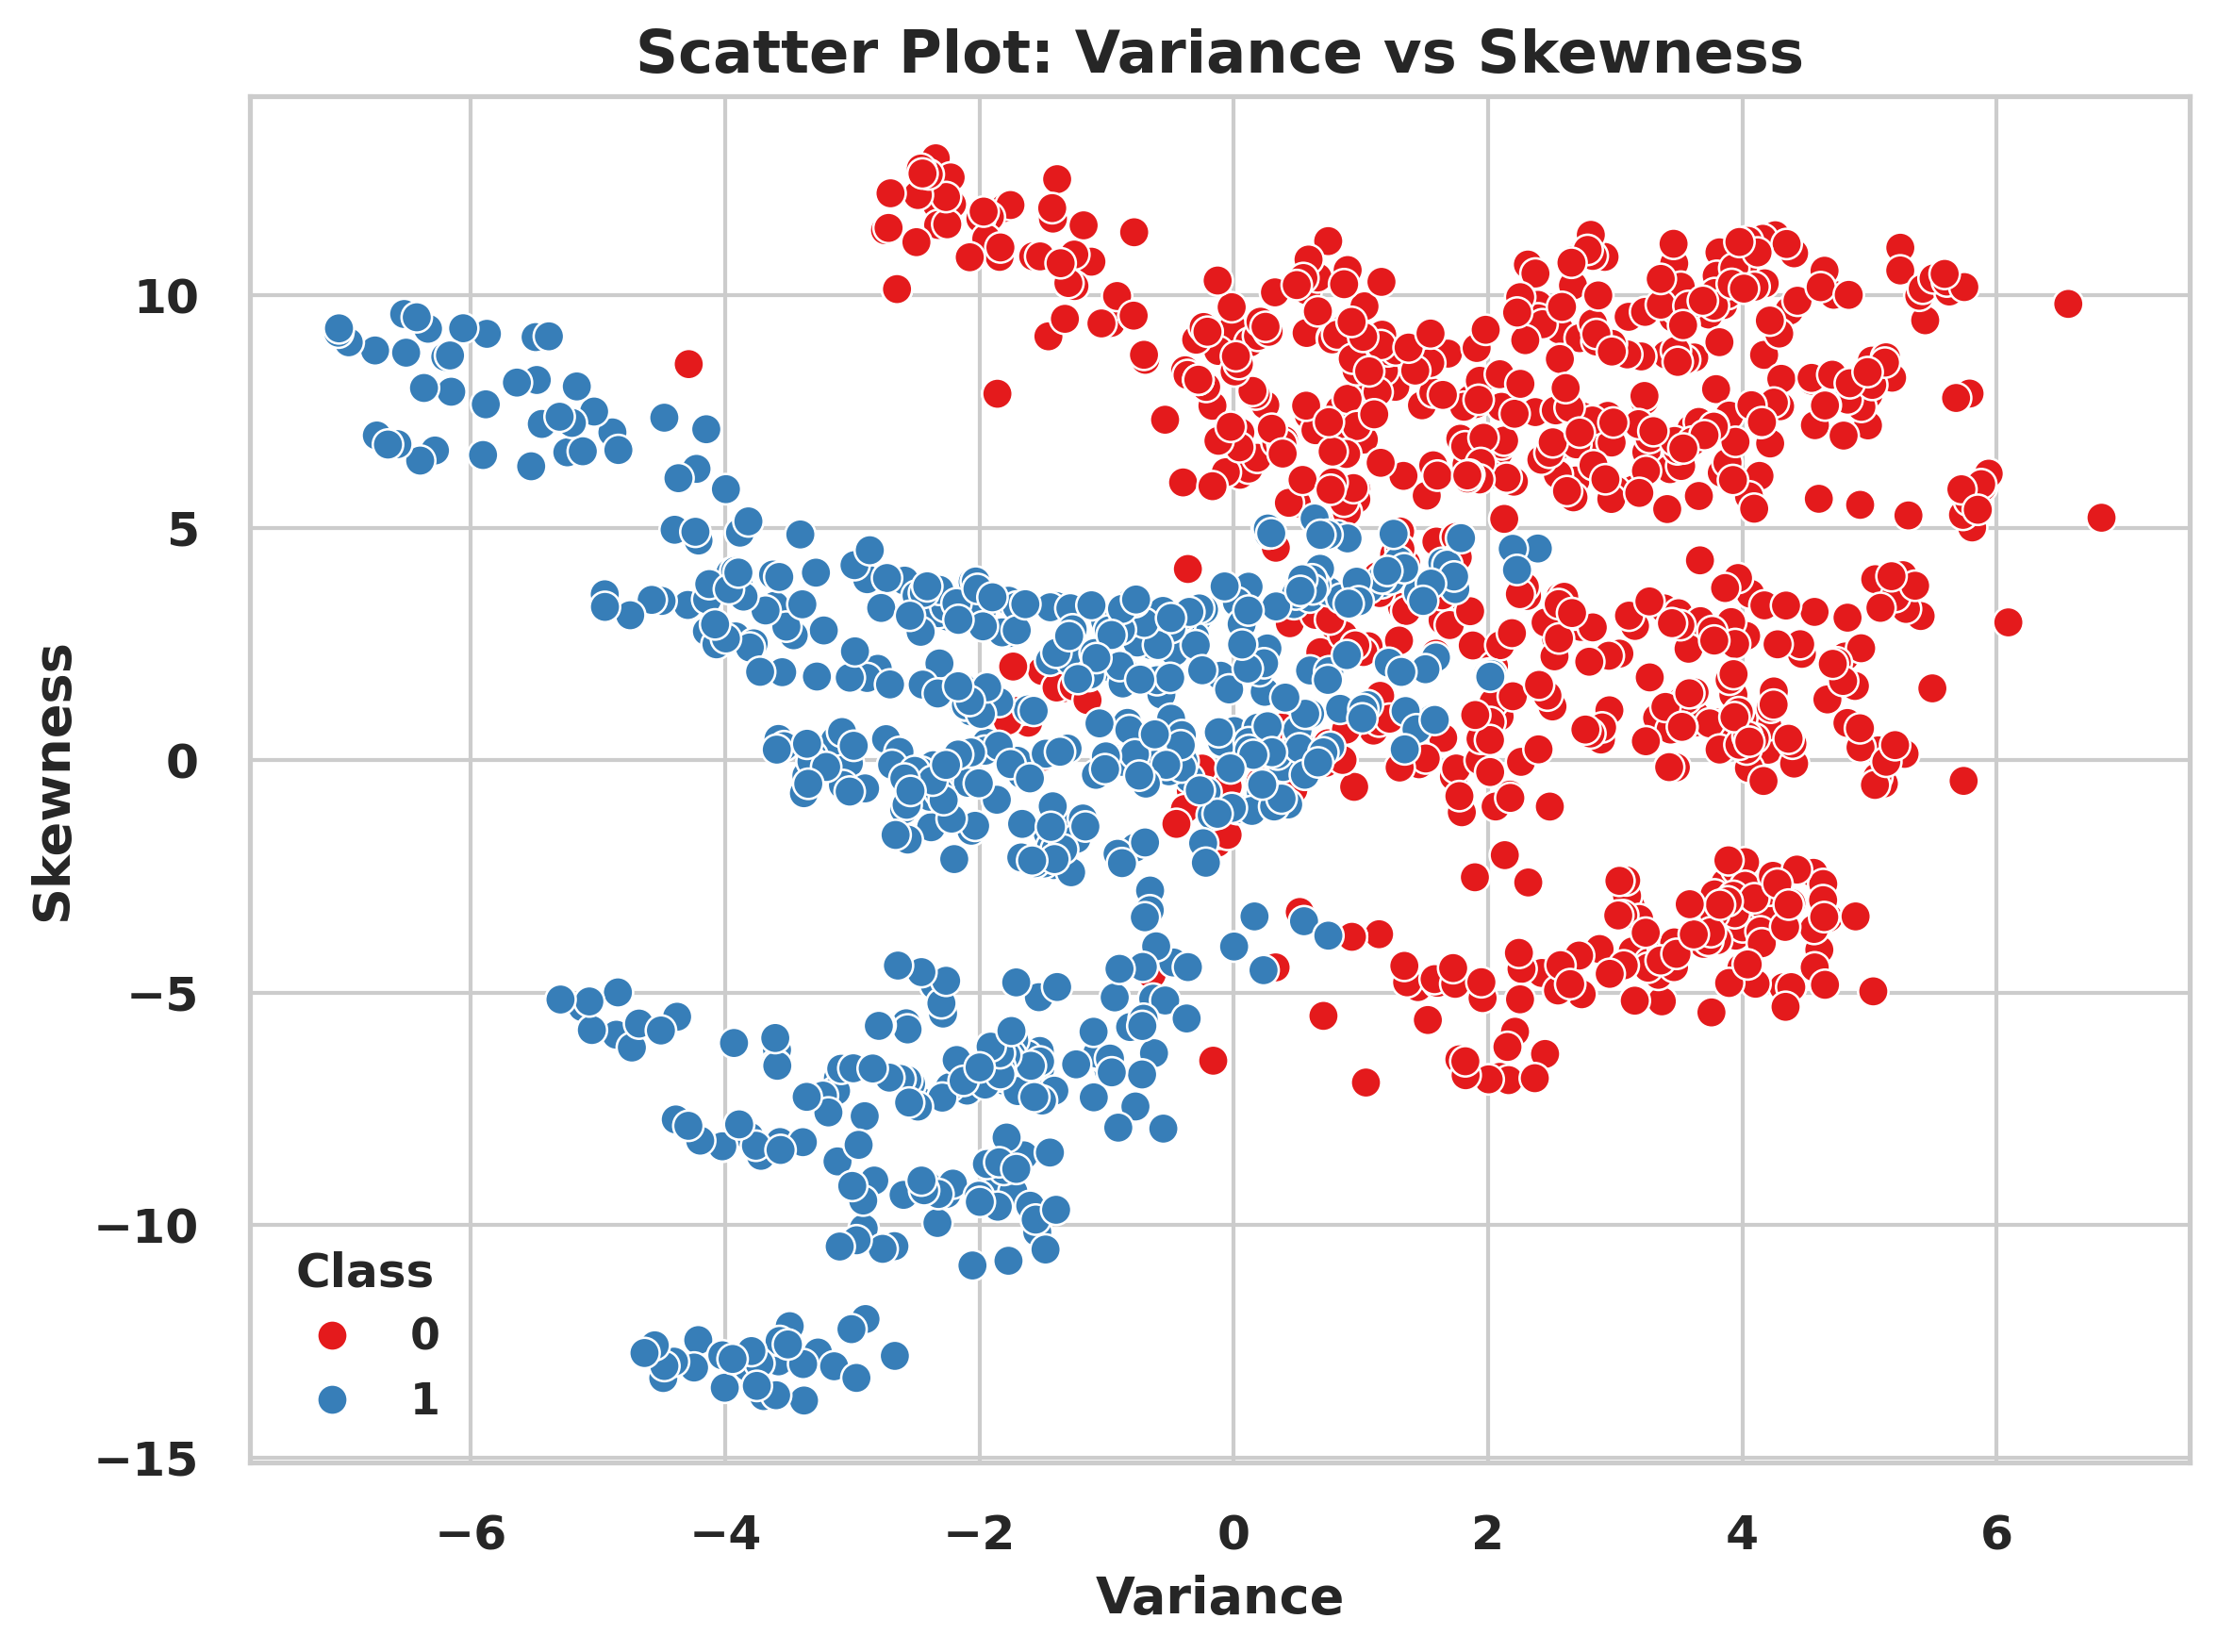

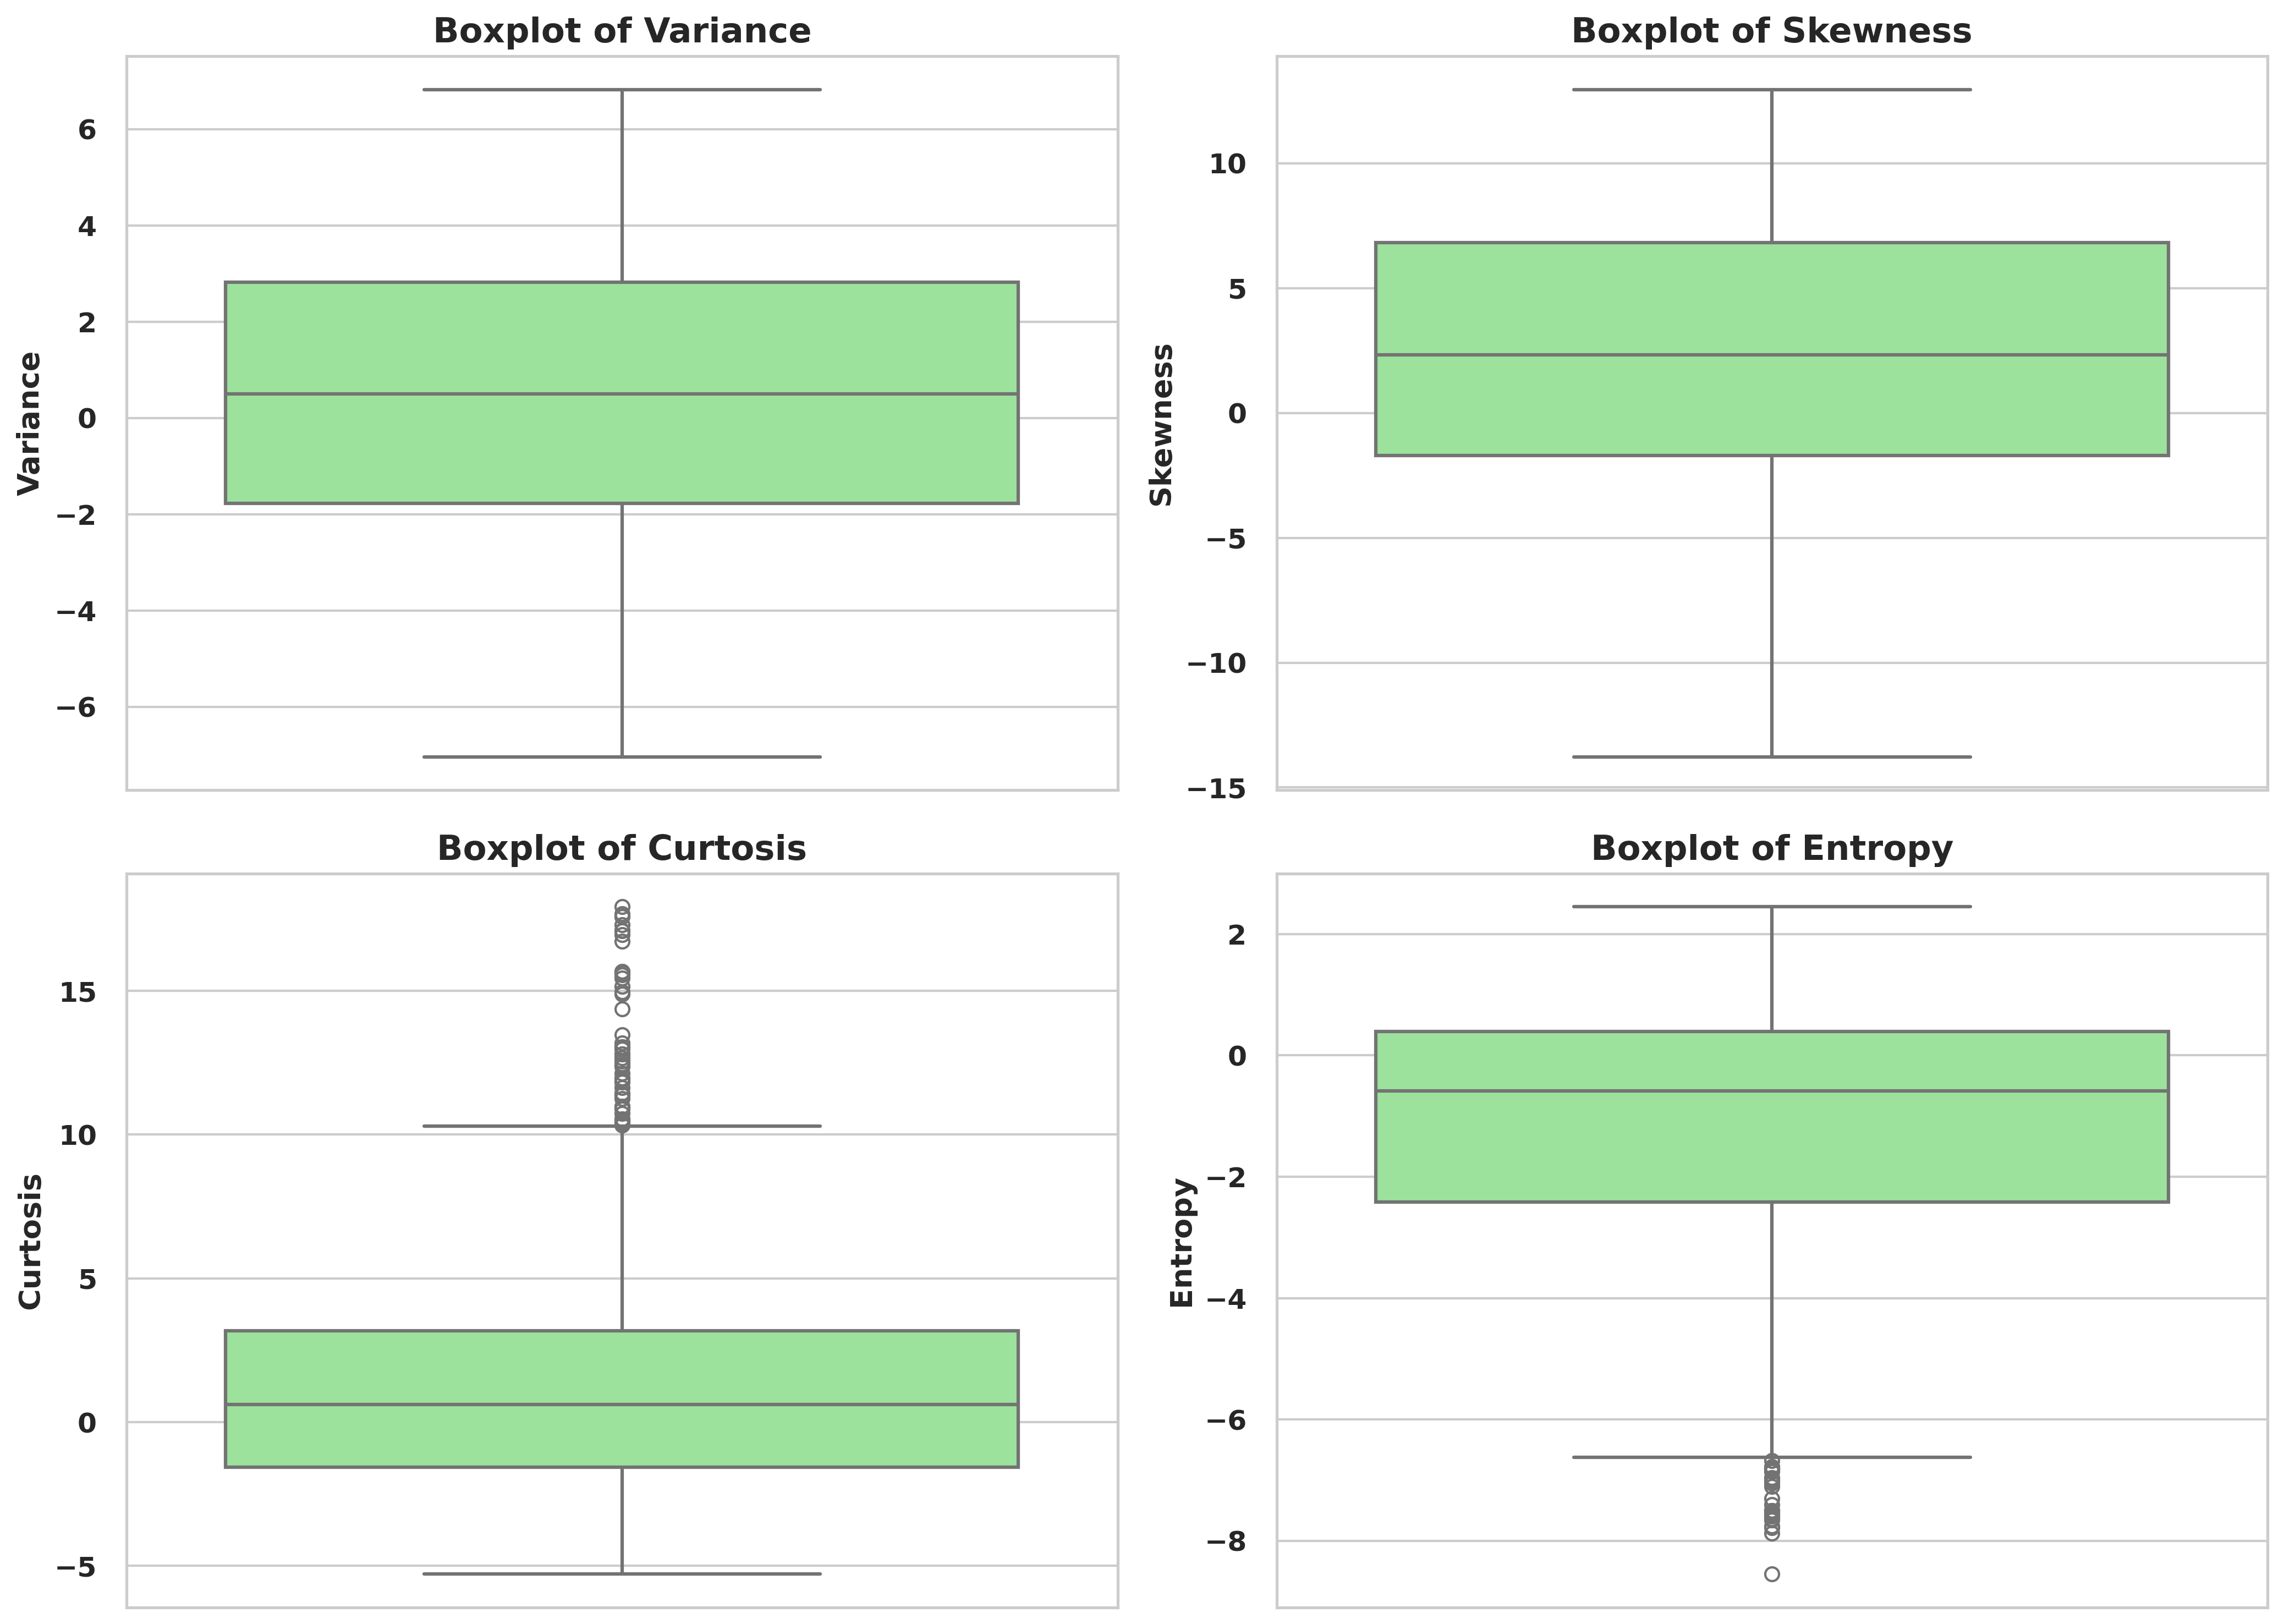

In [ ]:
#EDA

mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 13
mpl.rcParams['legend.fontsize'] = 11
mpl.rcParams['legend.title_fontsize'] = 12
sns.set_style("whitegrid")

# Feature names
features = df.columns[:-1]

#Histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
for ax, feature in zip(axes.flatten(), features):
    ax.hist(df[feature],
            bins=30,
            color='steelblue',
            edgecolor='black')
    ax.set_title(f'Histogram of {feature}', fontweight='bold')
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "histogram.eps"), format="eps", bbox_inches="tight")
plt.show()


#Correlation Heatmap
plt.figure(figsize=(8,6), dpi=300)
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    annot_kws={'weight':'bold'}
)
plt.title('Correlation Heatmap', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "correlation_heatmap.eps"), format="eps", bbox_inches="tight")
plt.show()


#Scatterplot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(
    data=df,
    x='Variance',
    y='Skewness',
    hue='Class',
    palette='Set1',
    s=60
)
plt.title('Scatter Plot: Variance vs Skewness', fontweight='bold')
plt.xlabel('Variance', fontweight='bold')
plt.ylabel('Skewness', fontweight='bold')
legend = plt.legend(title='Class')
legend.get_title().set_fontweight('bold')
for text in legend.get_texts():
    text.set_fontweight('bold')
for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')
plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "scatterplot.eps"), format="eps", bbox_inches="tight")
plt.show()


# Boxplot
fig, axes = plt.subplots(2,2, figsize=(14,10), dpi=300)
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        y=df[feature],
        color='lightgreen',
        linewidth=1.5,
        ax=ax
    )
    ax.set_title(f'Boxplot of {feature}', fontweight='bold')
    ax.set_ylabel(feature, fontweight='bold')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "boxplot.eps"), format="eps", bbox_inches="tight")
plt.show()

In [ ]:
#Data Preprocessing
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

#Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


y_train = np.where(y_train == 0, -1, 1)
y_test = np.where(y_test == 0, -1, 1)
print(" Training Labels :", np.unique(y_train))
print(" Testing Labels  :", np.unique(y_test))

Feature Matrix Shape : (1372, 4)
Target Vector Shape  : (1372,)
Training Samples : 1097
Testing Samples  : 275
 Training Labels : [-1  1]
 Testing Labels  : [-1  1]


In [ ]:
# Perceptron
class CustomPerceptron:

    def __init__(self, learning_rate=0.01):

        self.learning_rate = learning_rate

        self.weights = None

        self.bias = None

    def initialize_parameters(self, n_features):

        self.weights = np.zeros(n_features)
        self.bias = 0.0

    def step_activation(self, x):

        if x >= 0:
            return 1
        else:
            return -1

    def forward(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        prediction = self.step_activation(linear_output)

        return prediction


    def update_parameters(self, x_i, target, prediction):

        if target != prediction:

            self.weights += self.learning_rate * target * x_i

            self.bias += self.learning_rate * target

    def display_parameters(self):

        print("Initial Weights:")
        print(self.weights)

        print("\nInitial Bias:")
        print(self.bias)


In [ ]:
# Train
class CustomPerceptron(CustomPerceptron):

    def fit(self, X, y, epochs=20):

        self.initialize_parameters(X.shape[1])

        self.error_history = []
        self.weight_history = []
        self.bias_history = []

        print("=" * 80)
        print("Training Started")
        print("=" * 80)

        for epoch in range(epochs):

            misclassified = 0

            for x_i, target in zip(X, y):

                prediction = self.forward(x_i)

                if prediction != target:

                    self.update_parameters(x_i, target, prediction)
                    misclassified += 1

            self.error_history.append(misclassified)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"\nEpoch {epoch+1}/{epochs}")
            print("-" * 50)
            print(f"Misclassified Samples : {misclassified}")
            print(f"Updated Weights       : {self.weights}")
            print(f"Updated Bias          : {self.bias:.4f}")

            if misclassified == 0:
                print("\nTraining Converged Successfully!")
                break

        print("\n" + "=" * 80)
        print("Training Completed")
        print("=" * 80)

    def predict(self, X):

        predictions = []

        for sample in X:
            predictions.append(self.forward(sample))

        return np.array(predictions)


In [ ]:
perceptron = CustomPerceptron(learning_rate=0.01)
perceptron.fit(
    X_train,
    y_train,
    epochs=50
)


Training Started

Epoch 1/50
--------------------------------------------------
Misclassified Samples : 171
Updated Weights       : [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Updated Bias          : 0.0700

Epoch 2/50
--------------------------------------------------
Misclassified Samples : 101
Updated Weights       : [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Updated Bias          : 0.1000

Epoch 3/50
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Updated Bias          : 0.1100

Epoch 4/50
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Updated Bias          : 0.1200

Epoch 5/50
--------------------------------------------------
Misclassified Samples : 57
Updated Weights       : [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Updated Bias          : 0.1300

Epoch

In [ ]:
#Model
y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

cm = confusion_matrix(y_test, y_pred)

print("="*55)
print("           MODEL EVALUATION RESULTS")
print("="*55)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

           MODEL EVALUATION RESULTS
Accuracy  : 0.9891
Precision : 0.9917
Recall    : 0.9836
F1-score  : 0.9877

Confusion Matrix
[[152   1]
 [  2 120]]


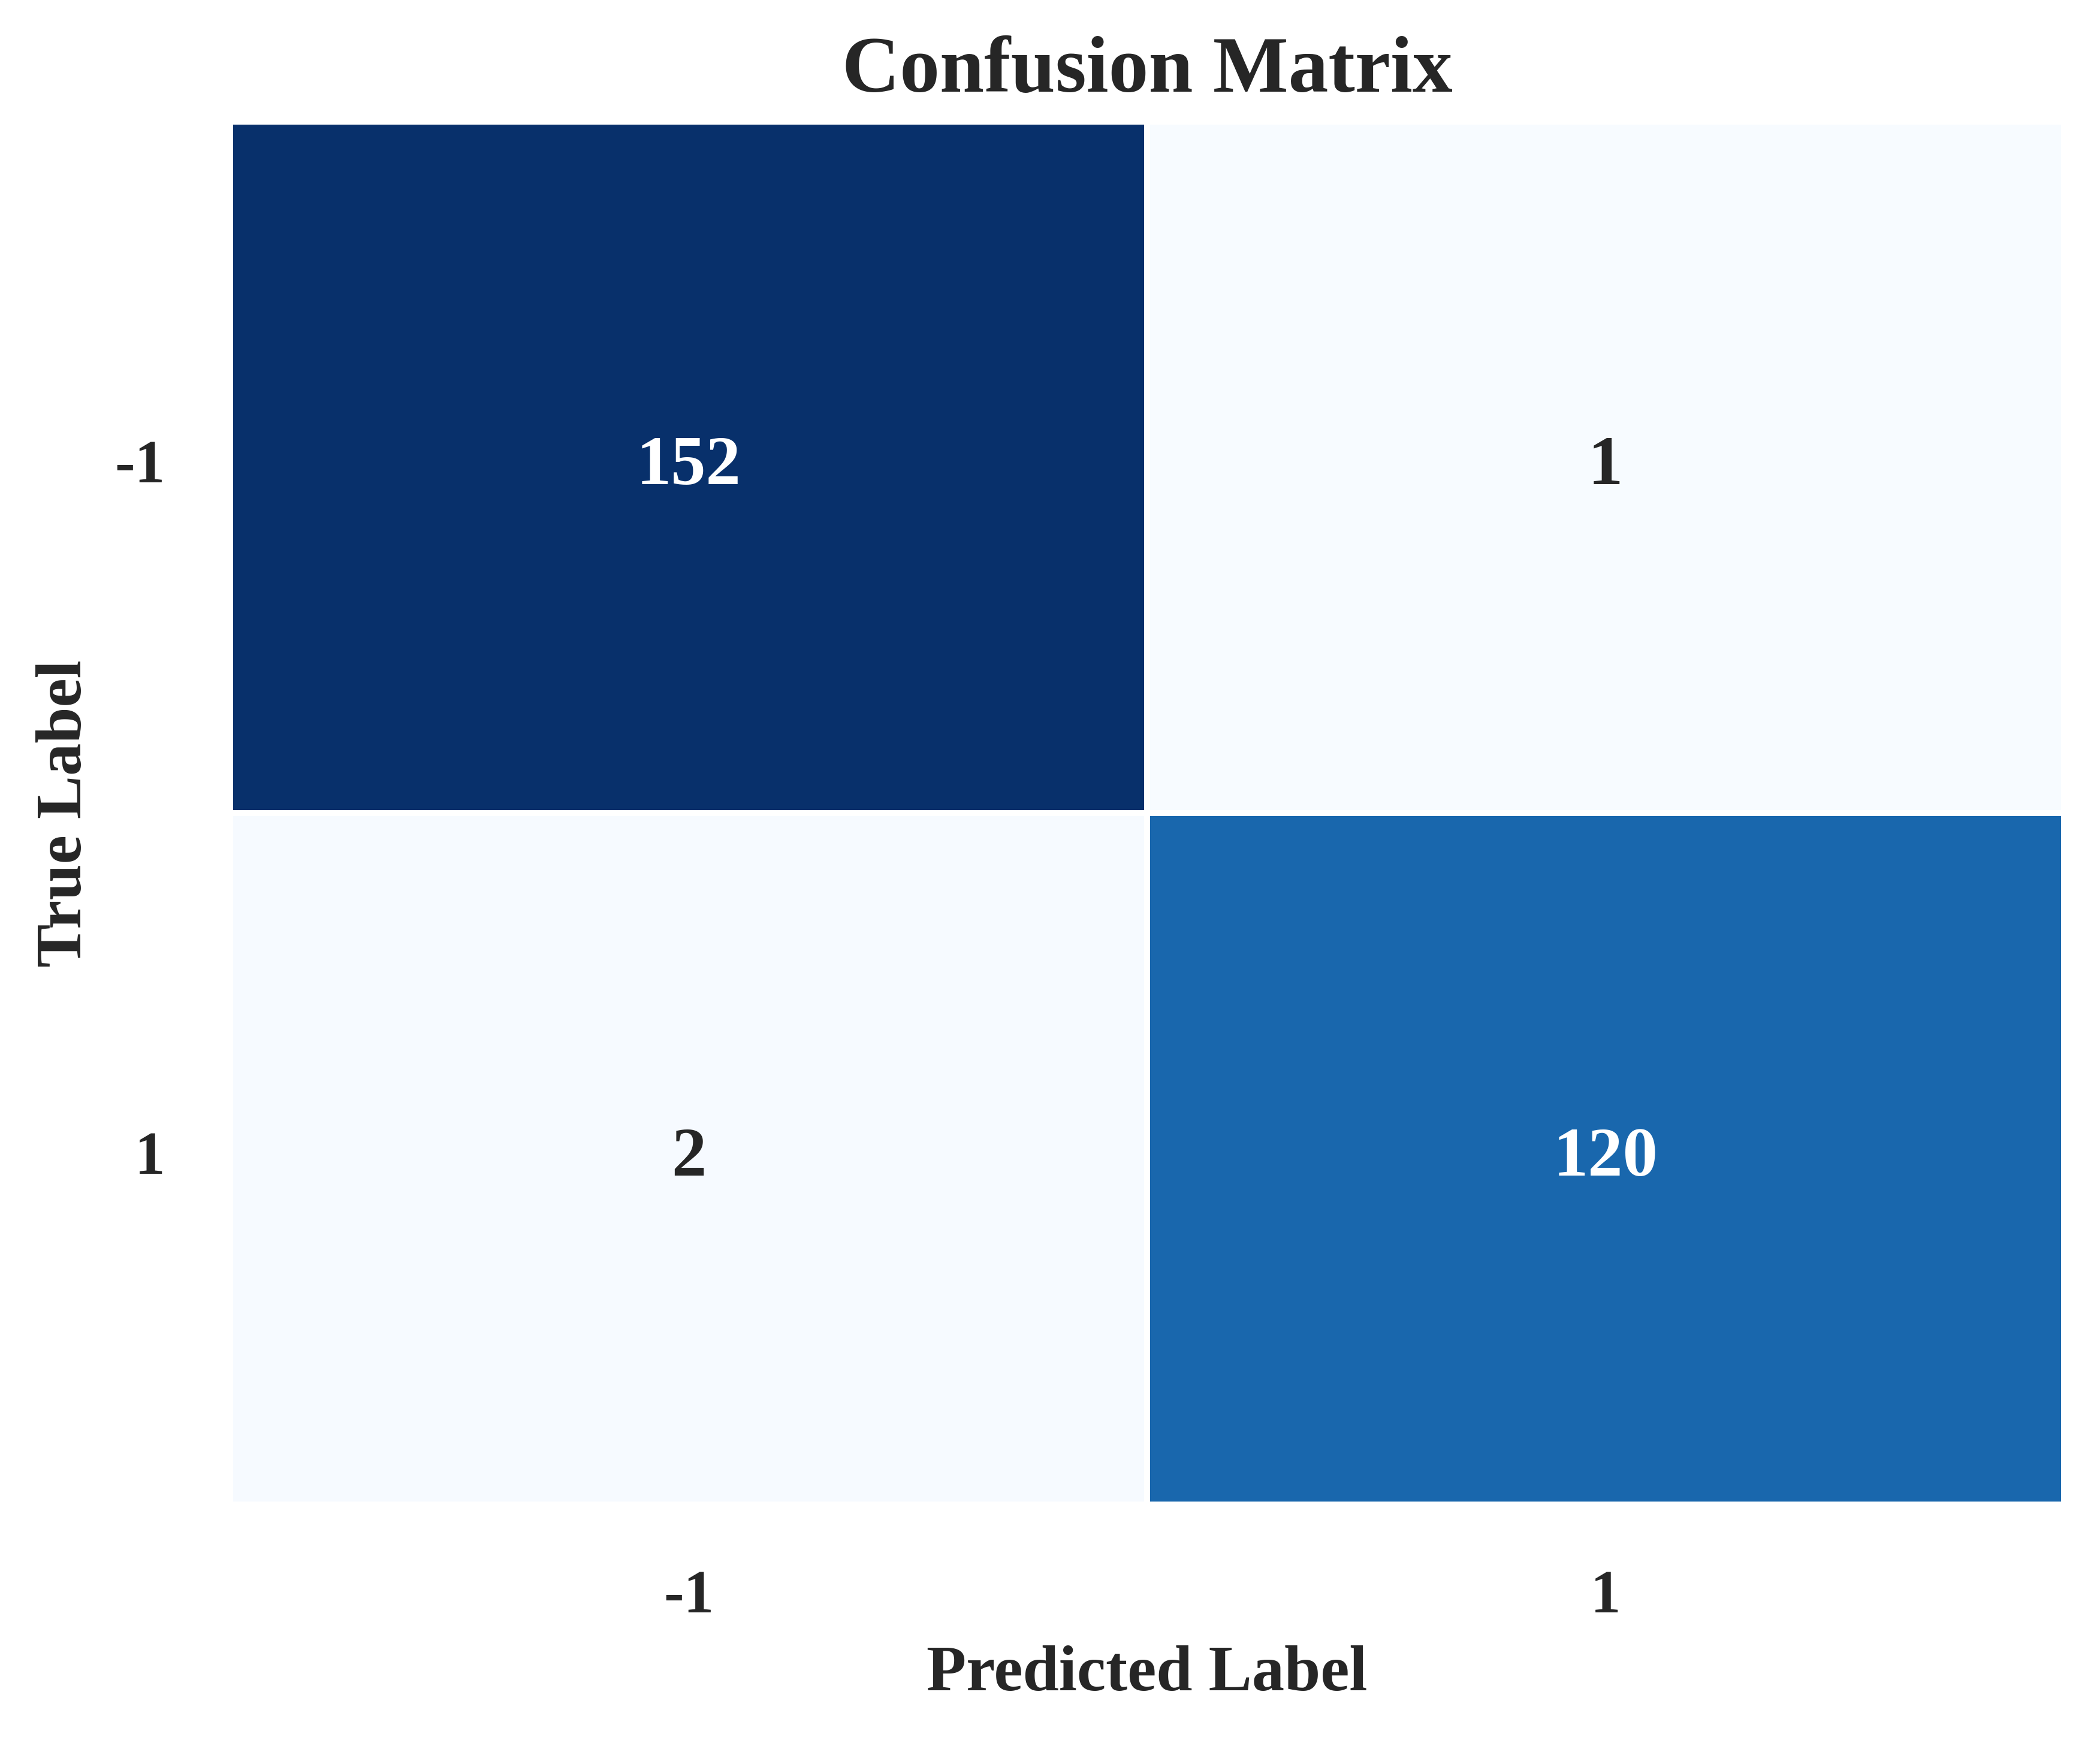

In [ ]:
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 12

plt.figure(figsize=(6,5), dpi=600)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    cbar=False,
    annot_kws={"fontsize":14, "fontweight":"bold"}
)

plt.title("Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
plt.ylabel("True Label", fontsize=13, fontweight='bold')

plt.xticks([0.5, 1.5], ['-1', '1'], fontweight='bold')
plt.yticks([0.5, 1.5], ['-1', '1'], rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "confusion_matrix.eps"), format="eps", bbox_inches="tight")
plt.show()

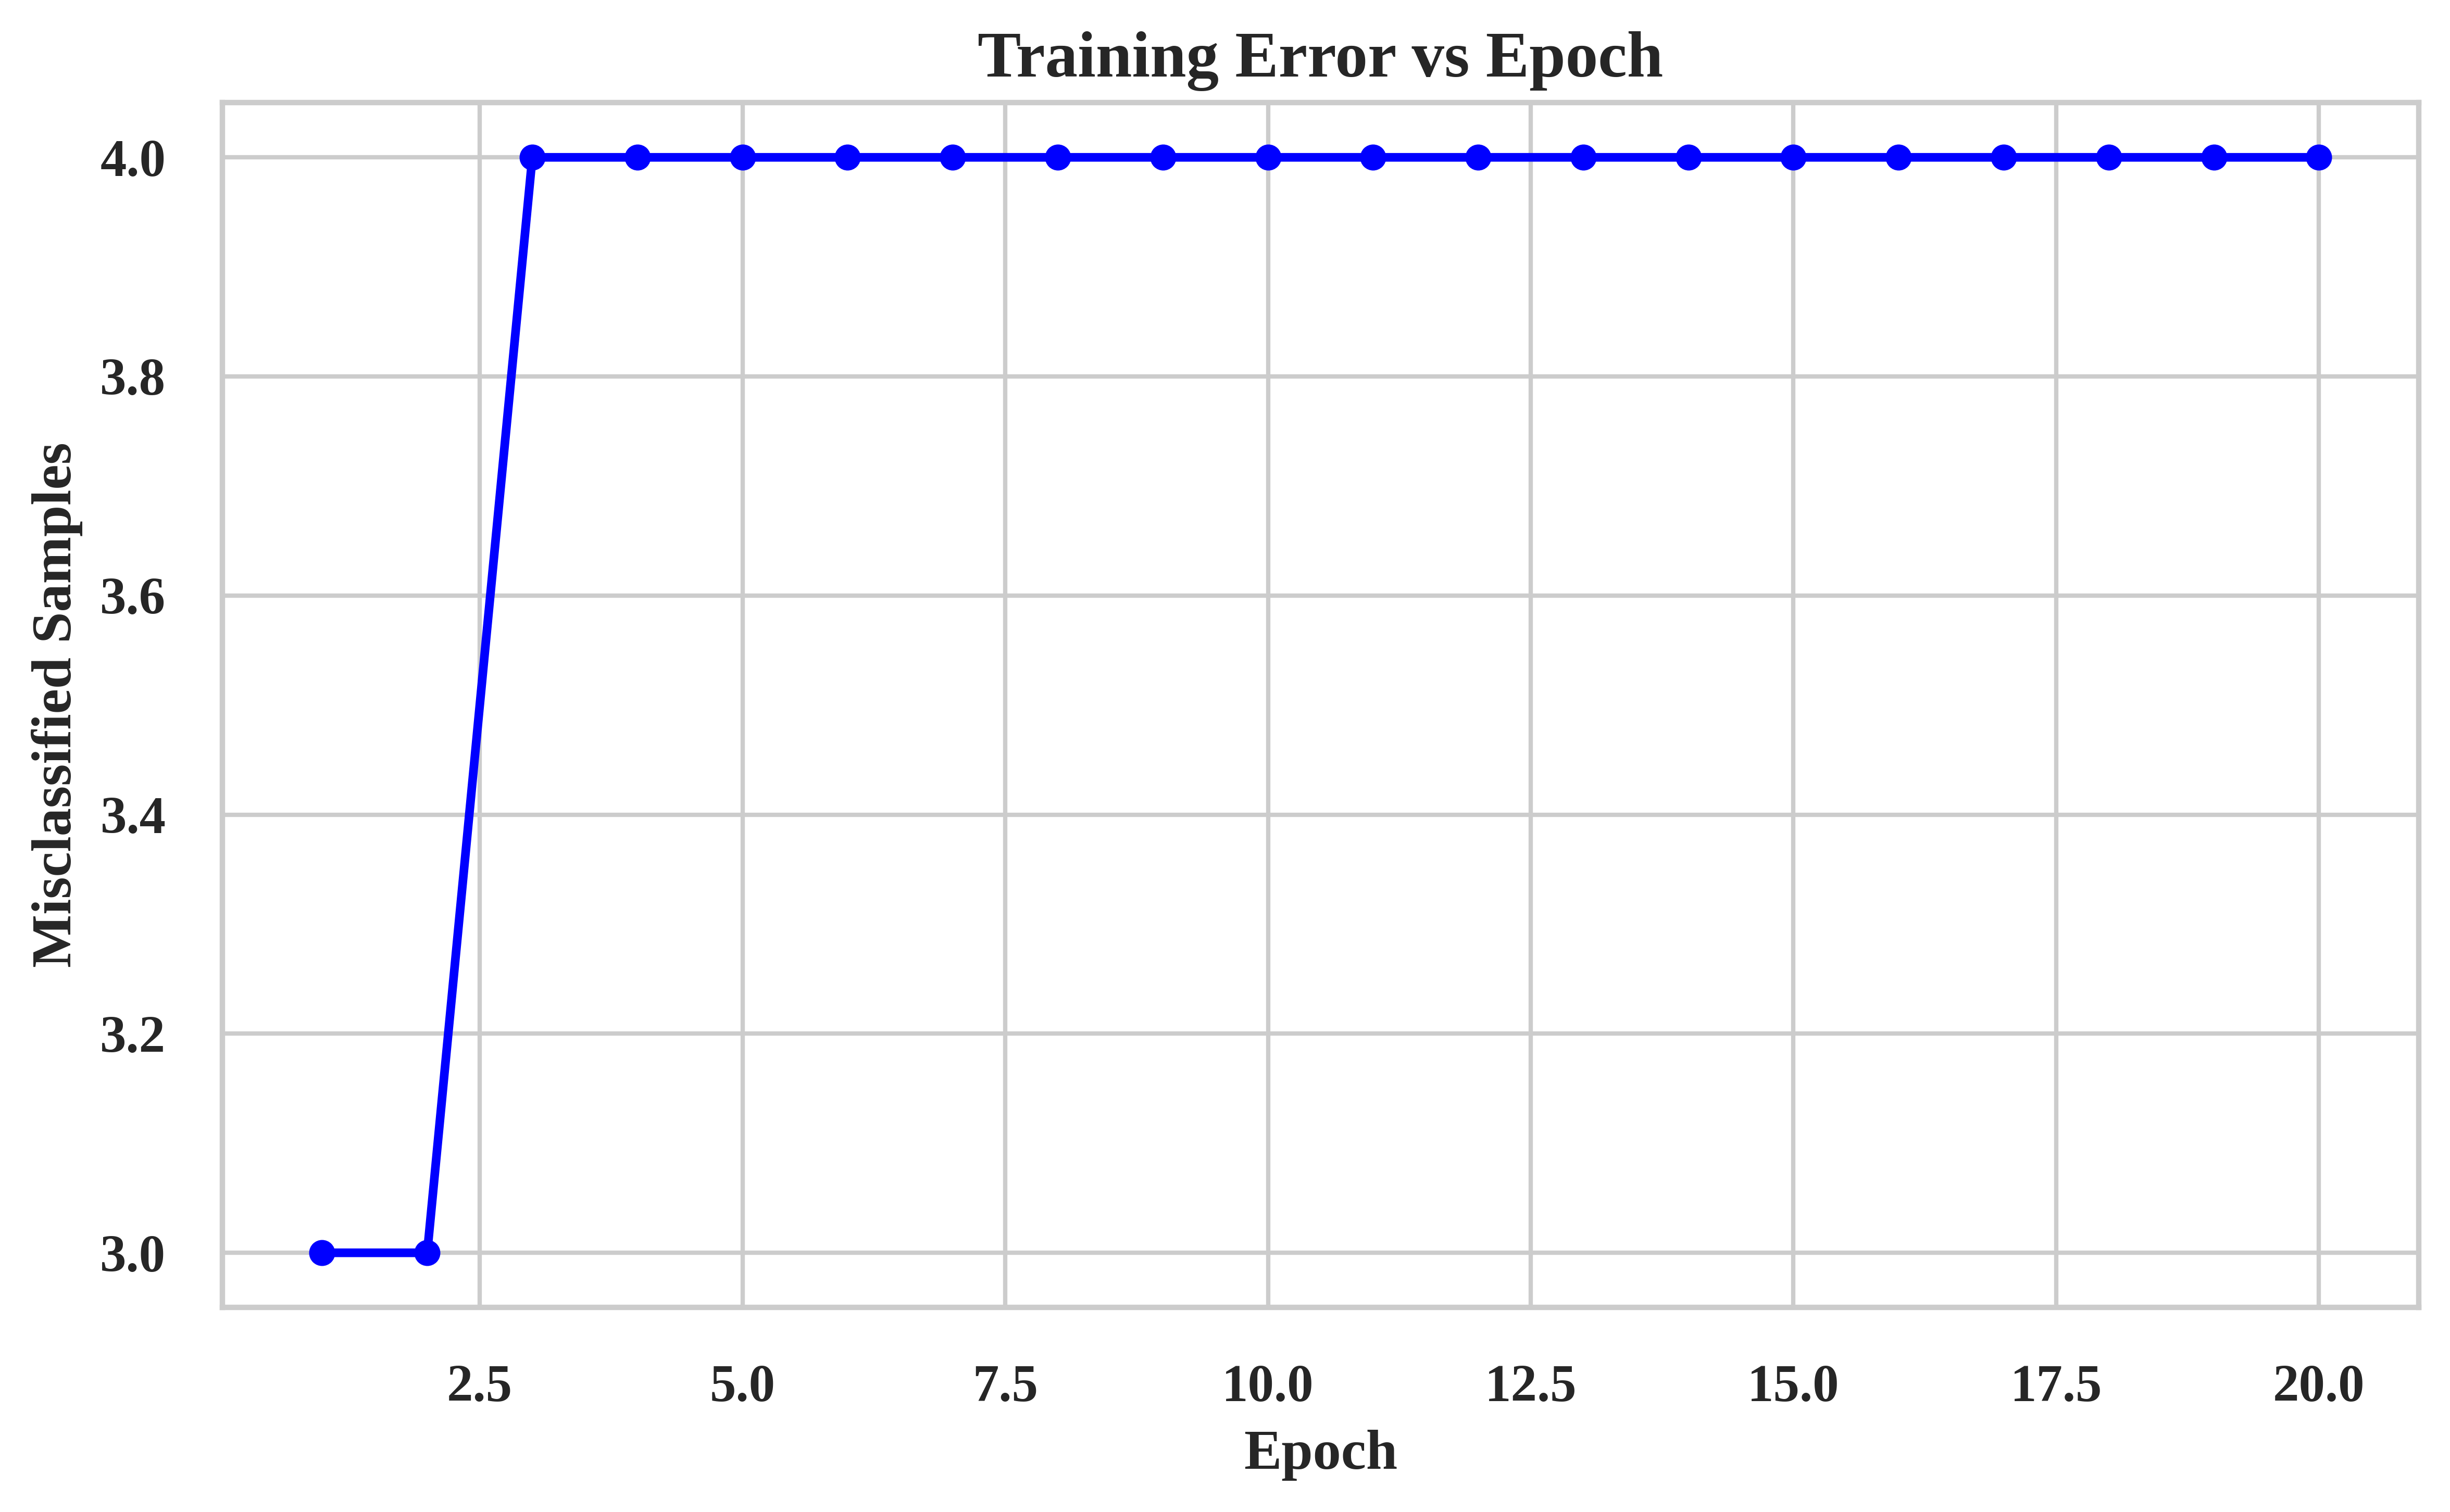

In [ ]:
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 12

epochs = range(1, len(perceptron.error_history) + 1)

plt.figure(figsize=(8,5), dpi=600)

plt.plot(
    epochs,
    perceptron.error_history,
    marker='o',
    linewidth=2,
    markersize=6,
    color='blue'
)

plt.title("Training Error vs Epoch", fontsize=15, fontweight='bold')
plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=13, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "training_error.eps"), format="eps", bbox_inches="tight")
plt.show()

In [ ]:
weights = np.array(perceptron.weight_history)

plt.figure(figsize=(9,6), dpi=600)

for i in range(weights.shape[1]):
    plt.plot(
        epochs,
        weights[:, i],
        marker='o',
        linewidth=2,
        label=f'Weight {i+1}'
    )

plt.title("Weight Evolution During Training", fontsize=15, fontweight='bold')
plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Weight Value", fontsize=13, fontweight='bold')

legend = plt.legend()

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "weight_evolution.eps"), format="eps", bbox_inches="tight")
plt.show()

AttributeError: 'Perceptron' object has no attribute 'weight_history'

In [ ]:
plt.figure(figsize=(8,5), dpi=600)

plt.plot(
    epochs,
    perceptron.bias_history,
    marker='s',
    linewidth=2,
    color='red'
)

plt.title("Bias Evolution During Training", fontsize=15, fontweight='bold')
plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Bias", fontsize=13, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(eps_output_dir, "bias_evolution.eps"), format="eps", bbox_inches="tight")
plt.show()

AttributeError: 'Perceptron' object has no attribute 'bias_history'

<Figure size 4800x3000 with 0 Axes>

In [ ]:
perceptron_001 = CustomPerceptron(learning_rate=0.1)

perceptron_001.fit(
    X_train,
    y_train,
    epochs=40
)


Training Started

Epoch 1/40
--------------------------------------------------
Misclassified Samples : 171
Updated Weights       : [-0.67923636 -0.46172775 -0.59042333  0.22136313]
Updated Bias          : 0.7000

Epoch 2/40
--------------------------------------------------
Misclassified Samples : 101
Updated Weights       : [-0.83805092 -0.67744656 -0.81059791  0.07755866]
Updated Bias          : 1.0000

Epoch 3/40
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.87805415 -0.78271216 -0.89452566  0.02402712]
Updated Bias          : 1.1000

Epoch 4/40
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.90819847 -0.89788935 -0.91232737  0.04391106]
Updated Bias          : 1.2000

Epoch 5/40
--------------------------------------------------
Misclassified Samples : 57
Updated Weights       : [-0.98789642 -0.98272793 -0.98363669  0.11080399]
Updated Bias          : 1.3000

Epoch

In [ ]:
perceptron_0001 = CustomPerceptron(learning_rate=0.001)

perceptron_0001.fit(
    X_train,
    y_train,
    epochs=20
)


Training Started

Epoch 1/20
--------------------------------------------------
Misclassified Samples : 171
Updated Weights       : [-0.00679236 -0.00461728 -0.00590423  0.00221363]
Updated Bias          : 0.0070

Epoch 2/20
--------------------------------------------------
Misclassified Samples : 101
Updated Weights       : [-0.00838051 -0.00677447 -0.00810598  0.00077559]
Updated Bias          : 0.0100

Epoch 3/20
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.00878054 -0.00782712 -0.00894526  0.00024027]
Updated Bias          : 0.0110

Epoch 4/20
--------------------------------------------------
Misclassified Samples : 43
Updated Weights       : [-0.00908198 -0.00897889 -0.00912327  0.00043911]
Updated Bias          : 0.0120

Epoch 5/20
--------------------------------------------------
Misclassified Samples : 57
Updated Weights       : [-0.00987896 -0.00982728 -0.00983637  0.00110804]
Updated Bias          : 0.0130

Epoch

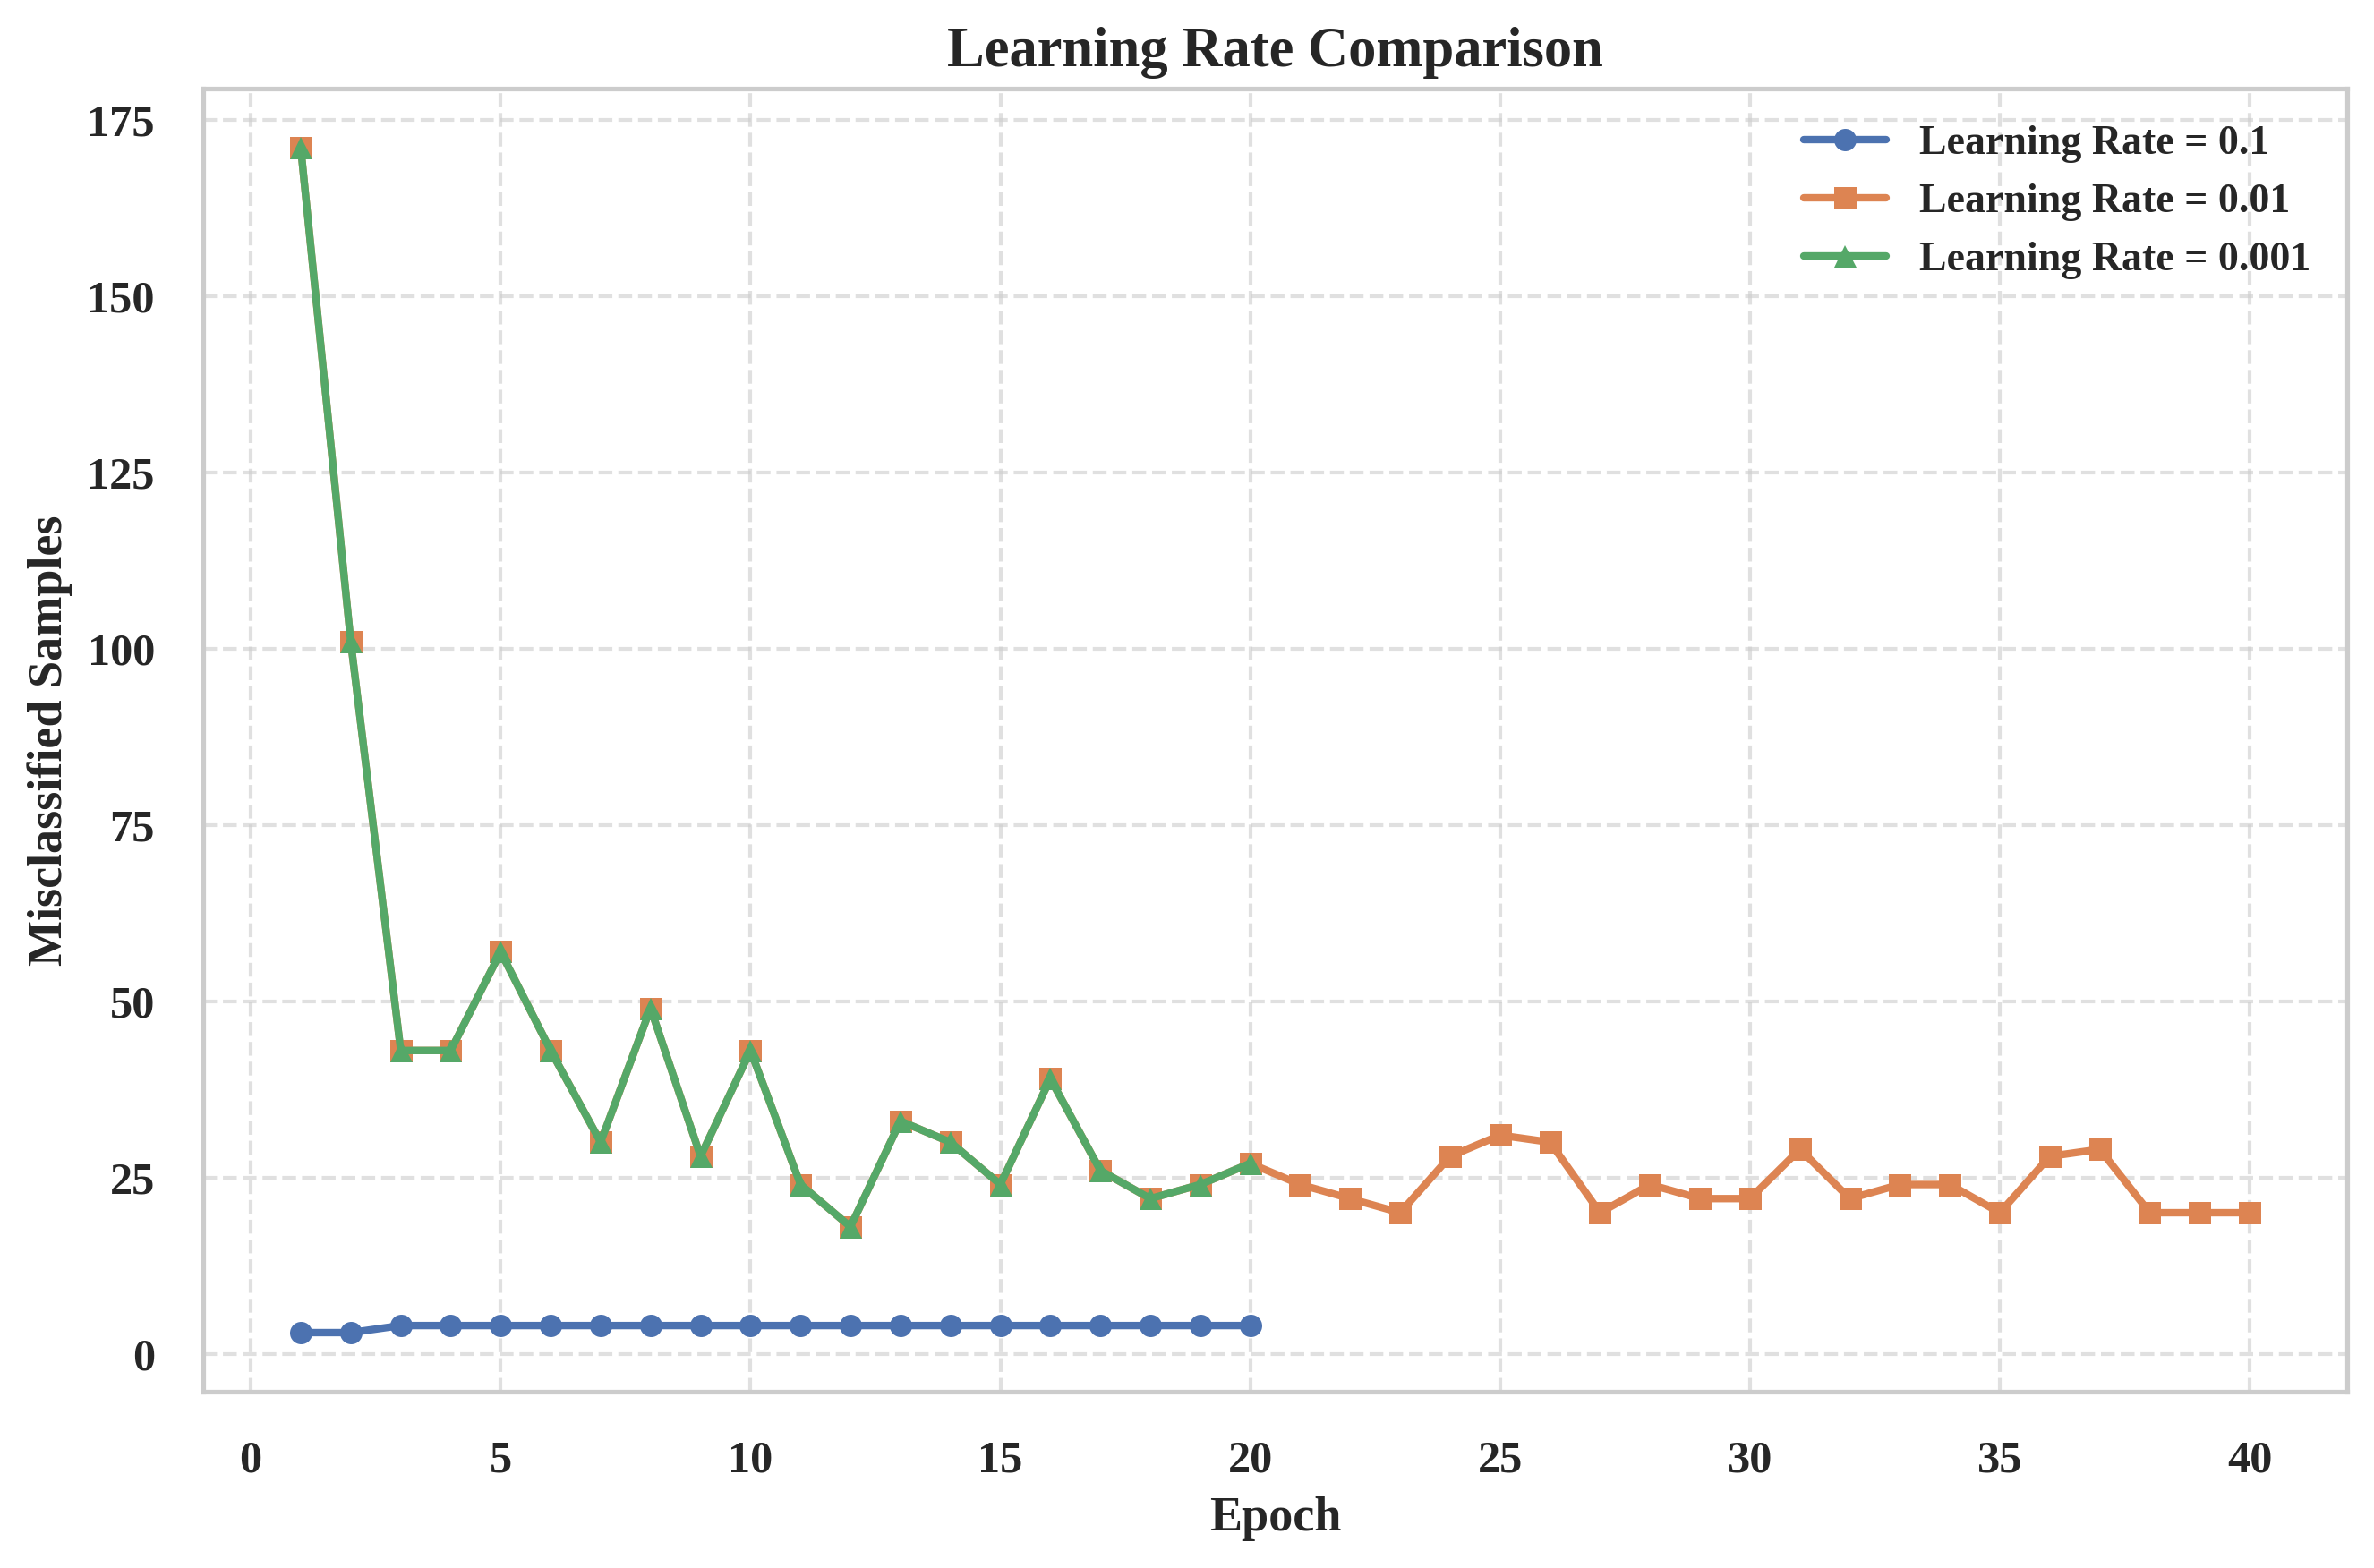

In [ ]:
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 12

plt.figure(figsize=(9,6), dpi=300)

plt.plot(
    range(1, len(perceptron.error_history)+1),
    perceptron.error_history,
    marker='o',
    linewidth=2,
    label='Learning Rate = 0.1'
)

plt.plot(
    range(1, len(perceptron_001.error_history)+1),
    perceptron_001.error_history,
    marker='s',
    linewidth=2,
    label='Learning Rate = 0.01'
)

plt.plot(
    range(1, len(perceptron_0001.error_history)+1),
    perceptron_0001.error_history,
    marker='^',
    linewidth=2,
    label='Learning Rate = 0.001'
)

plt.title("Learning Rate Comparison",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Epoch",
           fontsize=13,
           fontweight='bold')

plt.ylabel("Misclassified Samples",
           fontsize=13,
           fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(prop={'weight':'bold'})

plt.tight_layout()

plt.savefig(os.path.join(eps_output_dir, "learning_rate_comparison.eps"), format="eps", bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# Scikit-learn Perceptron Training and Evaluation

y_train_sk = np.where(y_train == -1, 0, 1)
y_test_sk = np.where(y_test == -1, 0, 1)

sk_perceptron = SklearnPerceptron(
    eta0=0.01,
    max_iter=50,
    tol=1e-3,
    random_state=42
)

sk_perceptron.fit(X_train, y_train_sk)

y_pred_sk = sk_perceptron.predict(X_test)

sk_accuracy = accuracy_score(y_test_sk, y_pred_sk)
sk_precision = precision_score(y_test_sk, y_pred_sk)
sk_recall = recall_score(y_test_sk, y_pred_sk)
sk_f1 = f1_score(y_test_sk, y_pred_sk)

print("="*60)
print("Scikit-learn Perceptron Results")
print("="*60)

print(f"Accuracy : {sk_accuracy:.4f}")
print(f"Precision: {sk_precision:.4f}")
print(f"Recall   : {sk_recall:.4f}")
print(f"F1-score : {sk_f1:.4f}")


Scikit-learn Perceptron Results
Accuracy : 0.9709
Precision: 0.9385
Recall   : 1.0000
F1-score : 0.9683


In [ ]:

manual_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

sklearn_results = {
    "Accuracy": sk_accuracy,
    "Precision": sk_precision,
    "Recall": sk_recall,
    "F1-score": sk_f1
}

comparison = pd.DataFrame(
    [manual_results, sklearn_results],
    index=["Manual Perceptron", "Scikit-learn Perceptron"]
)

comparison


,Accuracy,Precision,Recall,F1-score
Manual Perceptron,0.989091,0.991736,0.983607,0.987654
Scikit-learn Perceptron,0.970909,0.938462,1.000000,0.968254


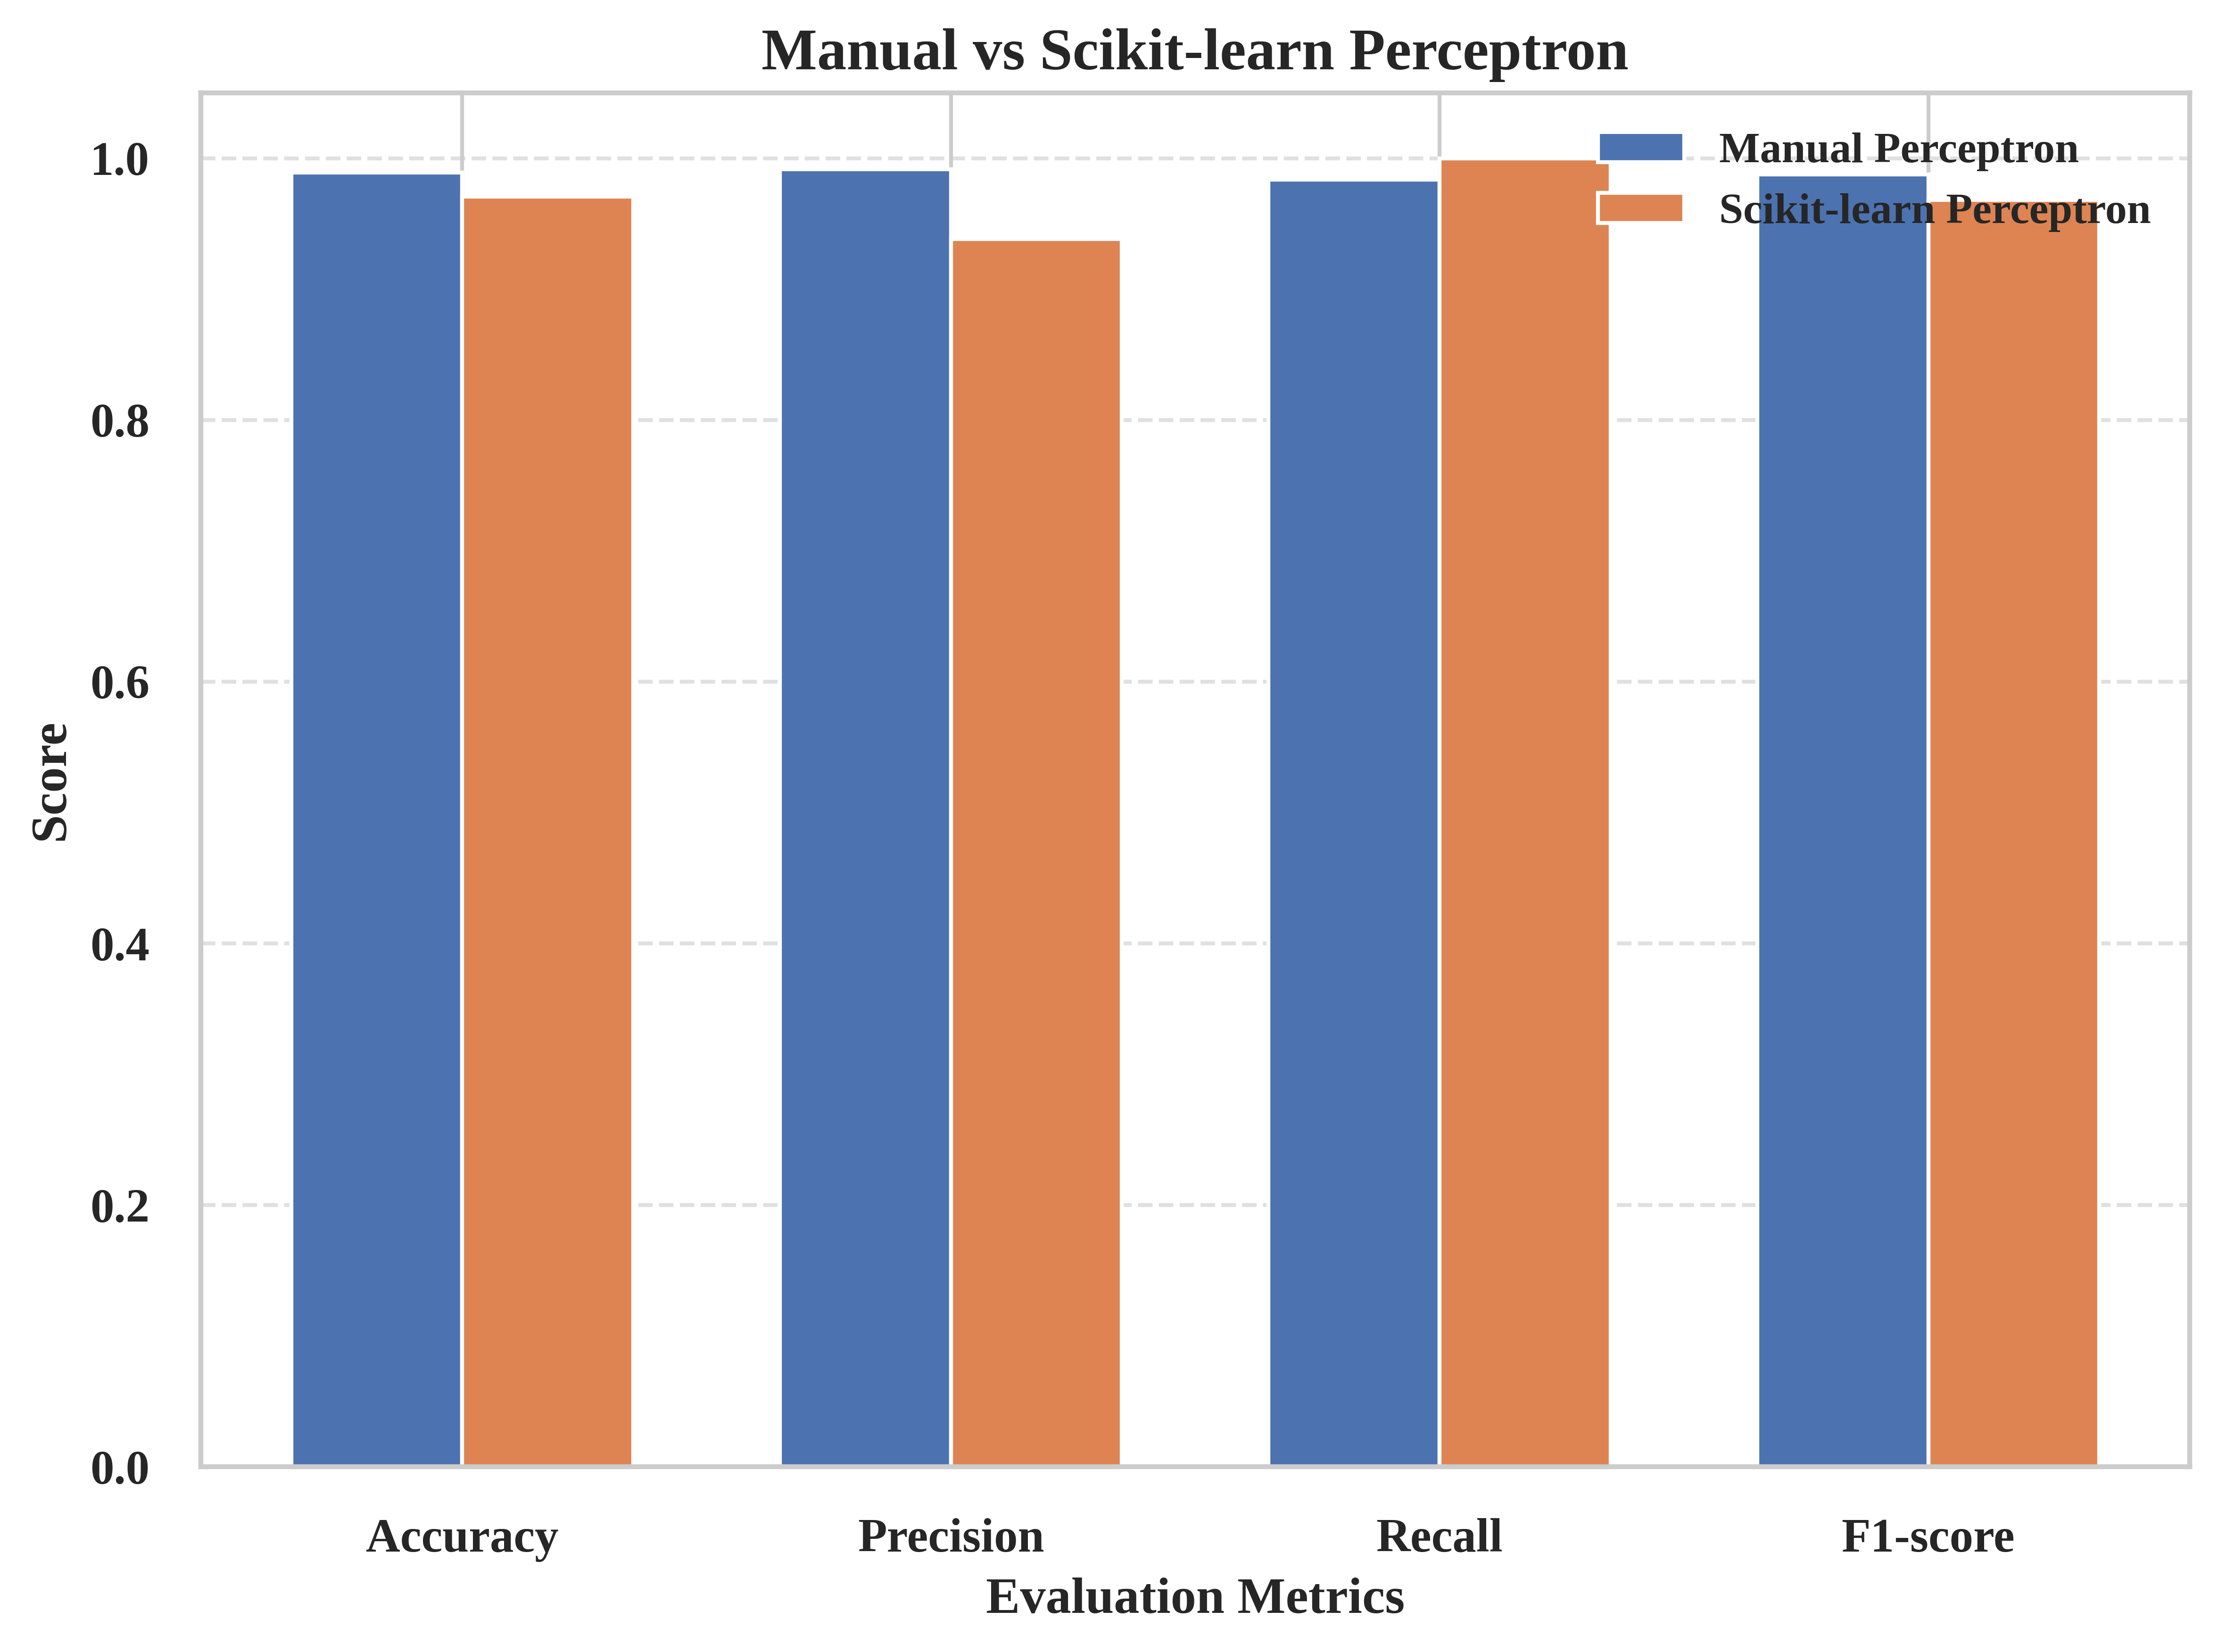

In [ ]:
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 12

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

manual = [
    accuracy,
    precision,
    recall,
    f1
]

sklearn = [
    sk_accuracy,
    sk_precision,
    sk_recall,
    sk_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,6), dpi=600)

plt.bar(
    x-width/2,
    manual,
    width,
    label='Manual Perceptron'
)

plt.bar(
    x+width/2,
    sklearn,
    width,
    label='Scikit-learn Perceptron'
)

plt.xticks(
    x,
    metrics,
    fontweight='bold'
)

plt.yticks(fontweight='bold')

plt.ylabel(
    "Score",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=13,
    fontweight='bold'
)

plt.title(
    "Manual vs Scikit-learn Perceptron",
    fontsize=15,
    fontweight='bold'
)

plt.legend(prop={'weight':'bold'})

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig(os.path.join(eps_output_dir, "manual_vs_sklearn_perceptron.eps"), format="eps", bbox_inches="tight")
plt.show()

Training Started

Epoch 1/20
--------------------------------------------------
Misclassified Samples : 247
Updated Weights       : [-0.64250769 -0.43602733]
Updated Bias          : 0.5000

Epoch 2/20
--------------------------------------------------
Misclassified Samples : 187
Updated Weights       : [-0.75145119 -0.42694396]
Updated Bias          : 0.6000

Epoch 3/20
--------------------------------------------------
Misclassified Samples : 200
Updated Weights       : [-0.78613565 -0.44754002]
Updated Bias          : 0.6000

Epoch 4/20
--------------------------------------------------
Misclassified Samples : 183
Updated Weights       : [-0.81948807 -0.45665308]
Updated Bias          : 0.7000

Epoch 5/20
--------------------------------------------------
Misclassified Samples : 180
Updated Weights       : [-0.77222964 -0.46653307]
Updated Bias          : 0.7000

Epoch 6/20
--------------------------------------------------
Misclassified Samples : 189
Updated Weights       : [-0.7843

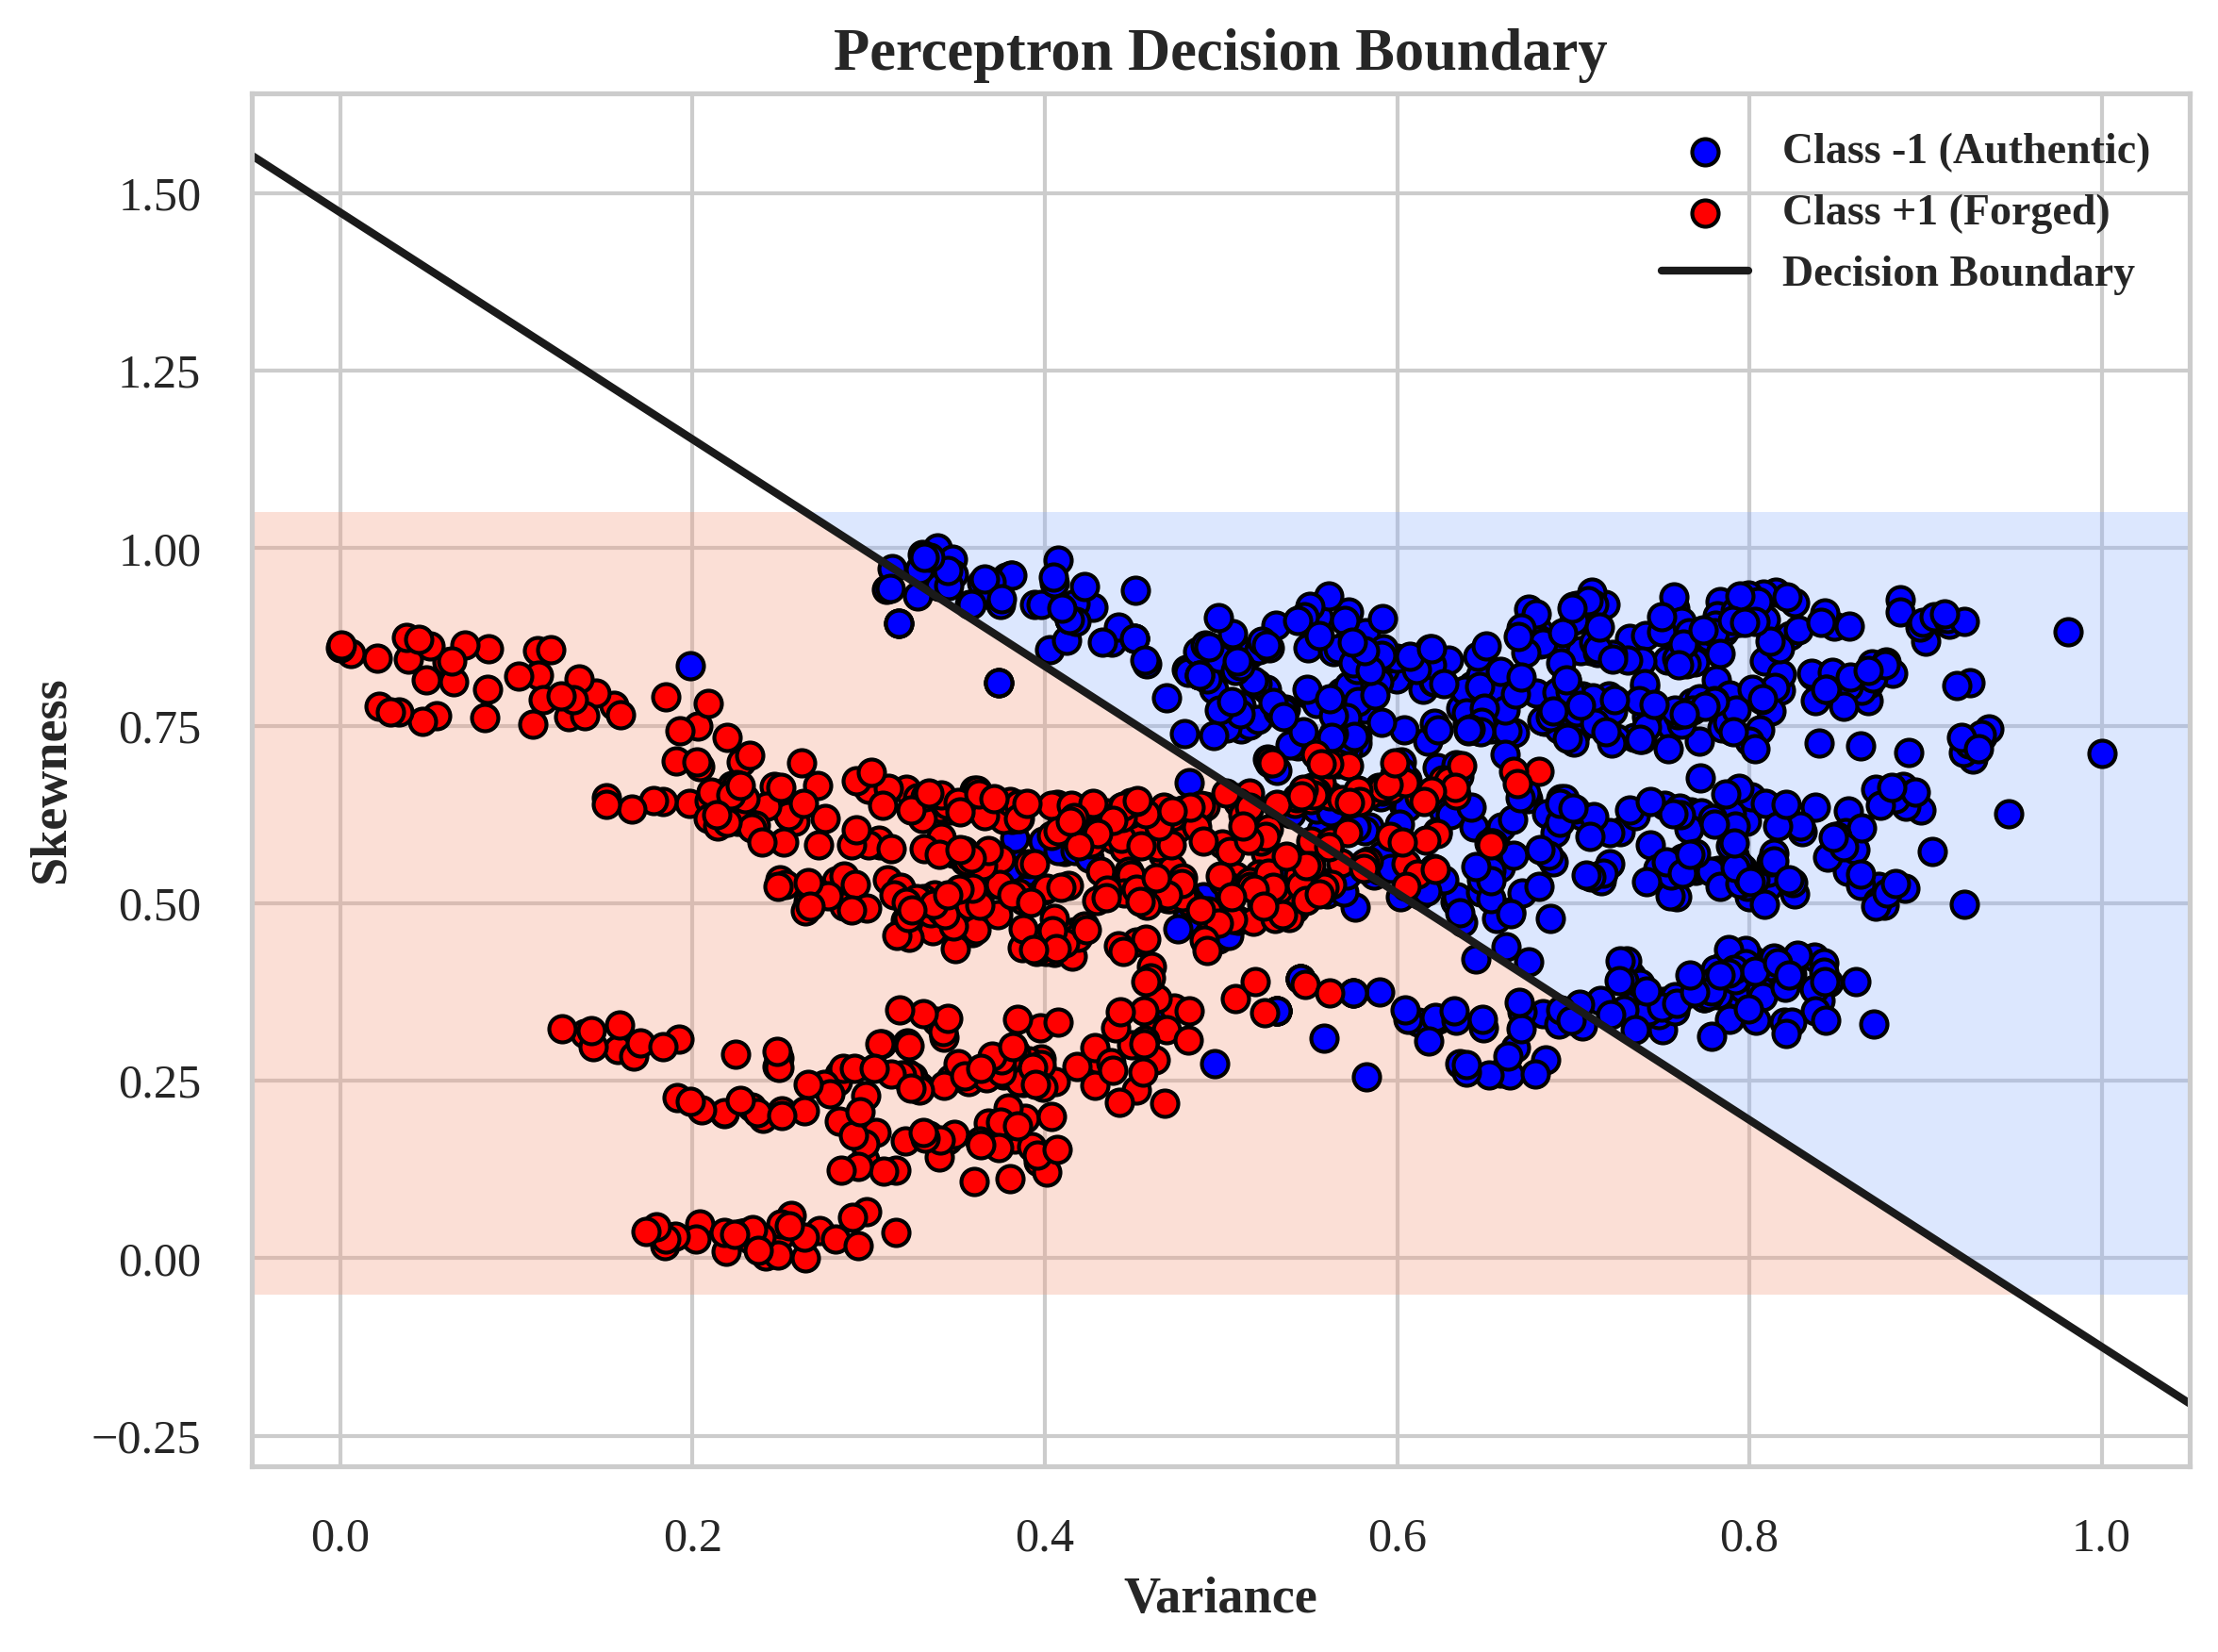

In [ ]:
# ==========================================================
# Decision Boundary (-1 vs +1 Classes)
# Using Variance and Skewness (First Two Features)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Use only first two features
# ----------------------------------------------------------

X_db = X_scaled[:, :2]          # Variance and Skewness
y_db = np.where(df["Class"] == 0, -1, 1)

# ----------------------------------------------------------
# Train-Test Split
# ----------------------------------------------------------

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db,
    y_db,
    test_size=0.2,
    random_state=42,
    stratify=y_db
)

# ----------------------------------------------------------
# Train Manual Perceptron
# ----------------------------------------------------------

boundary_model = CustomPerceptron(learning_rate=0.1)
boundary_model.fit(X_train_db, y_train_db, epochs=20)

# ----------------------------------------------------------
# Mesh Grid
# ----------------------------------------------------------

x_min, x_max = X_db[:,0].min()-0.05, X_db[:,0].max()+0.05
y_min, y_max = X_db[:,1].min()-0.05, X_db[:,1].max()+0.05

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict every point
Z = boundary_model.predict(grid)
Z = Z.reshape(xx.shape)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6), dpi=300)

# Decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.30,
    levels=[-1,0,1],
    cmap='coolwarm'
)

# Plot Class -1
plt.scatter(
    X_db[y_db==-1,0],
    X_db[y_db==-1,1],
    color='blue',
    edgecolor='black',
    label='Class -1 (Authentic)',
    s=45
)

# Plot Class +1
plt.scatter(
    X_db[y_db==1,0],
    X_db[y_db==1,1],
    color='red',
    edgecolor='black',
    label='Class +1 (Forged)',
    s=45
)

# Draw Decision Boundary
w = boundary_model.weights
b = boundary_model.bias

x_values = np.array([x_min, x_max])
y_values = -(w[0]*x_values + b)/w[1]

plt.plot(
    x_values,
    y_values,
    'k-',
    linewidth=2,
    label='Decision Boundary'
)

plt.title(
    "Perceptron Decision Boundary",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Variance",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Skewness",
    fontsize=13,
    fontweight='bold'
)

plt.legend(prop={'weight':'bold'})

plt.grid(True)

plt.tight_layout()

plt.savefig(os.path.join(eps_output_dir, "decision_boundary.eps"), format="eps", bbox_inches="tight")
plt.show()

In [ ]:
#xor

import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([-1, 1, 1, -1])

print("Inputs")
print(X)

print("\nTargets")
print(y)

Inputs
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Targets
[-1  1  1 -1]


In [ ]:
class XORPerceptron:

    def __init__(self, learning_rate=0.1, epochs=20):

        self.lr = learning_rate
        self.epochs = epochs

        self.weights = np.zeros(2)
        self.bias = 0

    def activation(self, x):

        if x >= 0:
            return 1
        else:
            return -1

    def predict(self, X):

        linear = np.dot(X, self.weights) + self.bias

        return self.activation(linear)

    def fit(self, X, y):

        self.error_history = []

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi)

                if prediction != target:

                    self.weights += self.lr * target * xi
                    self.bias += self.lr * target

                    errors += 1

            self.error_history.append(errors)

        print("Final Weights :", self.weights)
        print("Final Bias    :", self.bias)

In [ ]:
class XORPerceptron:

    def __init__(self, learning_rate=0.1, epochs=20):

        self.lr = learning_rate
        self.epochs = epochs

        self.weights = np.zeros(2)
        self.bias = 0

    def activation(self, x):

        if x >= 0:
            return 1
        else:
            return -1

    def predict(self, X):

        linear = np.dot(X, self.weights) + self.bias

        return self.activation(linear)

    def fit(self, X, y):

        self.error_history = []

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi);

                if prediction != target:

                    self.weights += self.lr * target * xi
                    self.bias += self.lr * target

                    errors += 1

            self.error_history.append(errors)

        print("Final Weights :", self.weights)
        print("Final Bias    :", self.bias)

xor_perceptron = XORPerceptron(
    learning_rate=0.1,
    epochs=20
)
xor_perceptron.fit(X, y)

Final Weights : [-0.1  0. ]
Final Bias    : 0.0


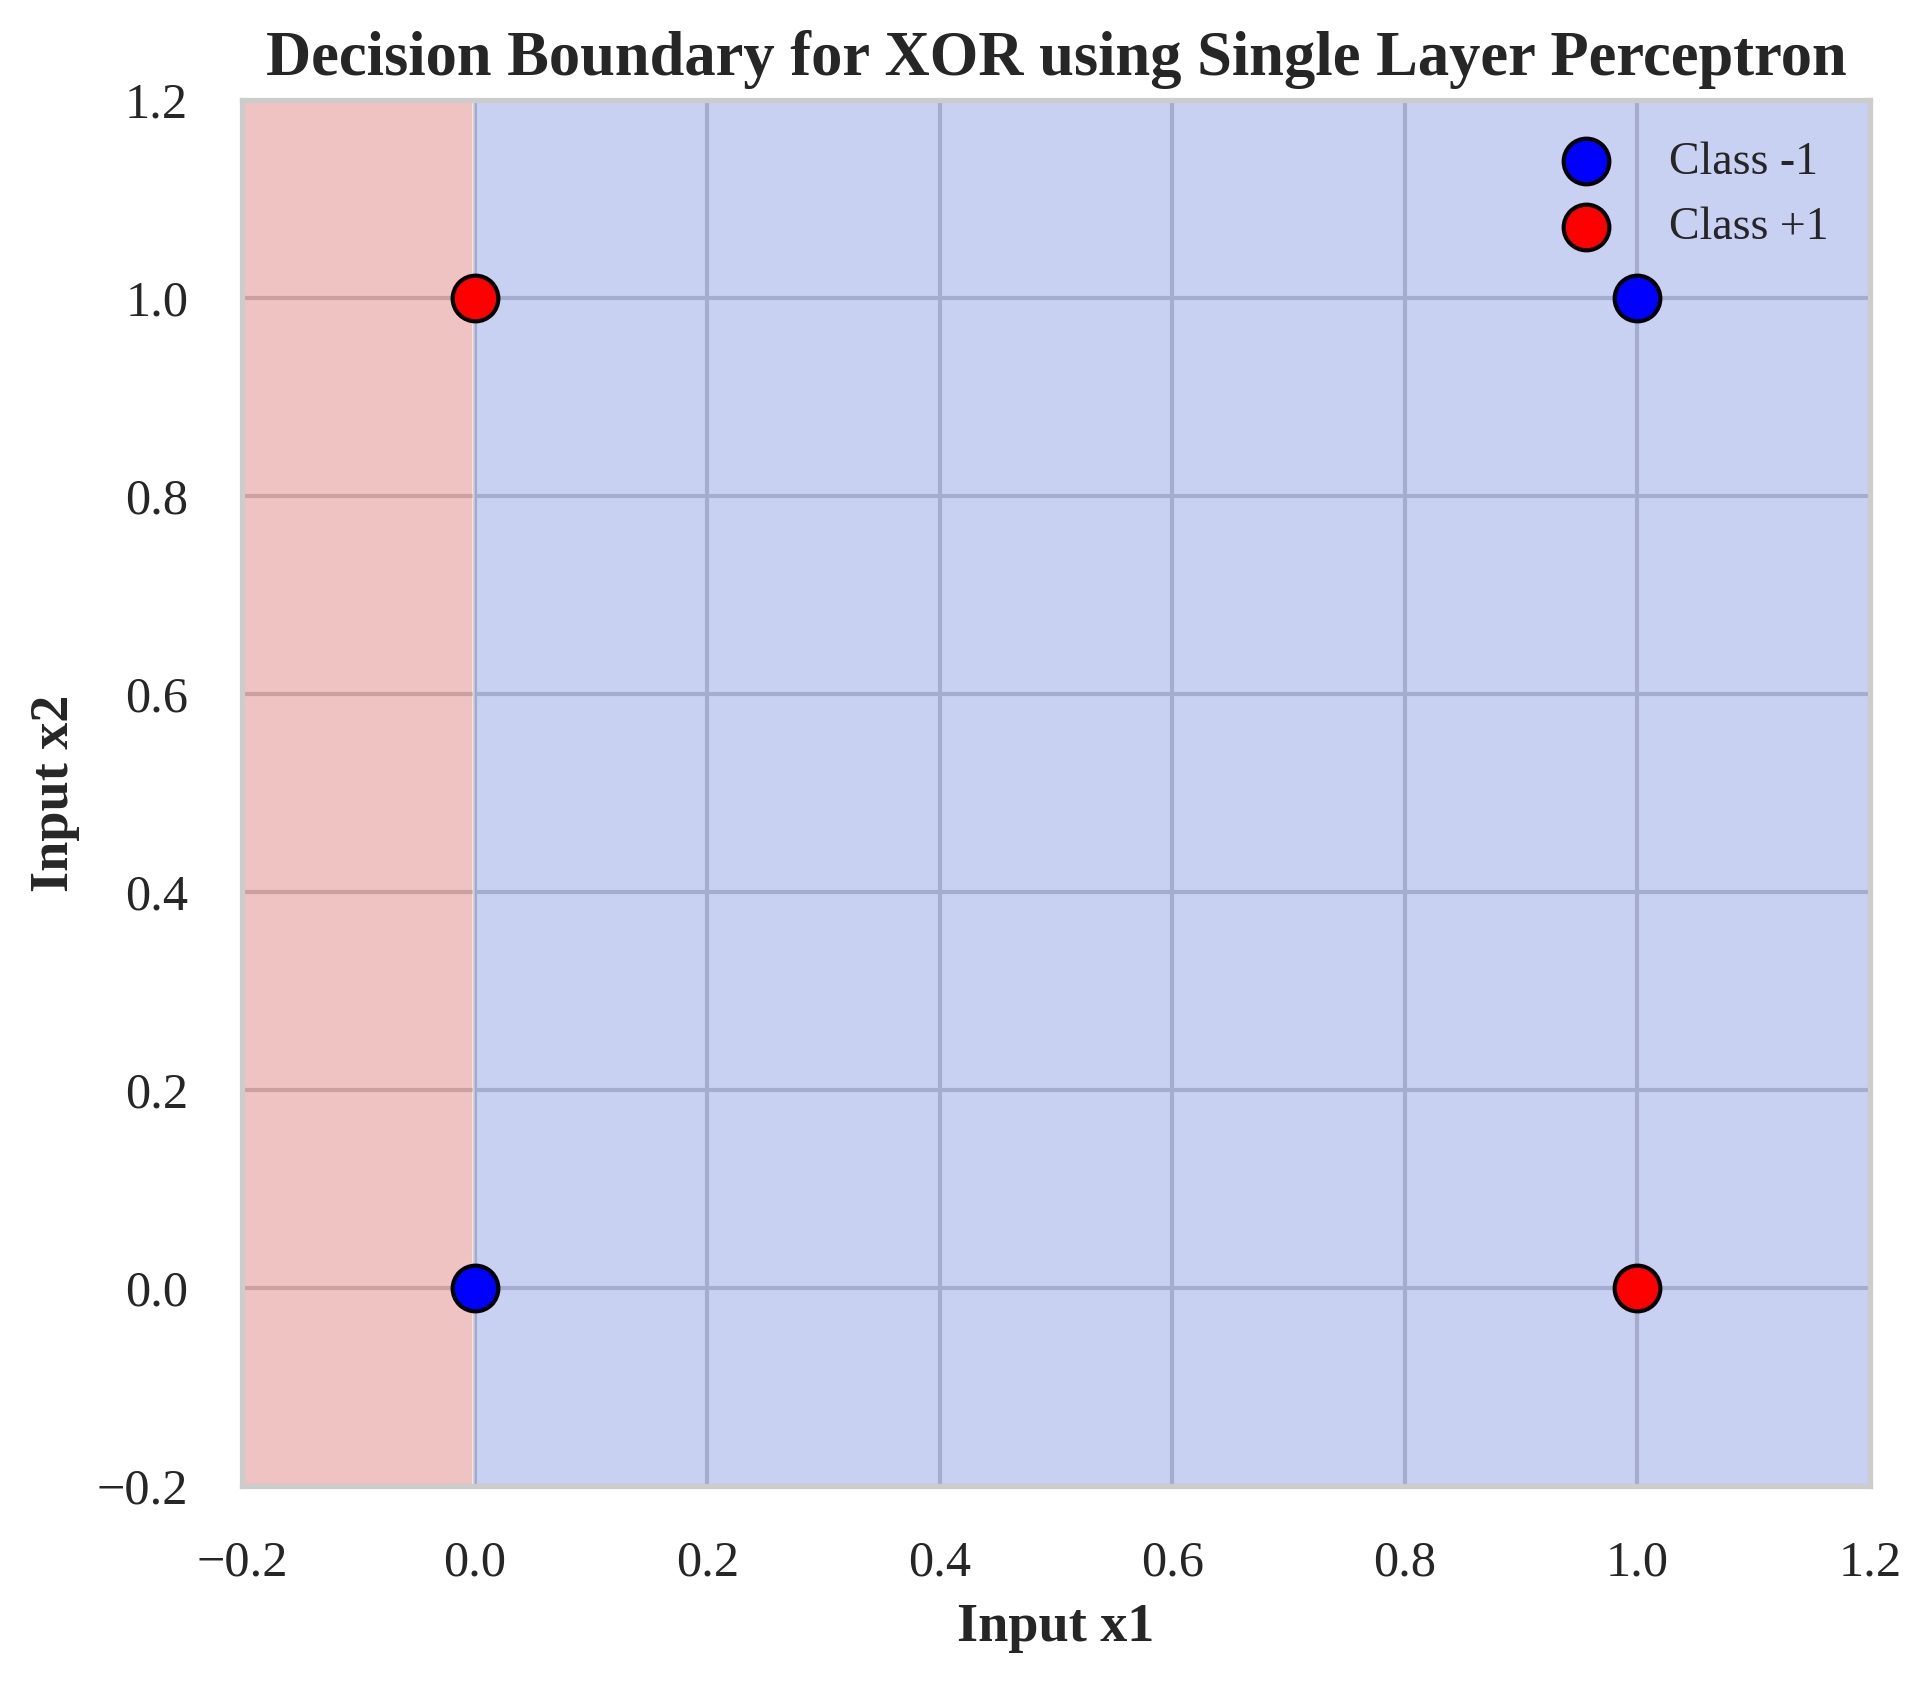

In [ ]:
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

predictions = []

for point in grid:
    predictions.append(xor_perceptron.predict(point))

predictions = np.array(predictions)
predictions = predictions.reshape(xx.shape)

plt.figure(figsize=(7,6), dpi=300)

plt.contourf(
    xx,
    yy,
    predictions,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X[y==-1][:,0],
    X[y==-1][:,1],
    c='blue',
    s=120,
    edgecolor='black',
    label='Class -1'
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    c='red',
    s=120,
    edgecolor='black',
    label='Class +1'
)
w = xor_perceptron.weights
b = xor_perceptron.bias

if abs(w[1]) > 1e-6:

    x_values = np.array([x_min, x_max])

    y_values = -(w[0]*x_values + b)/w[1]

    plt.plot(
        x_values,
        y_values,
        'k-',
        linewidth=2,
        label='Decision Boundary'
    )

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("Input x1", fontweight='bold')
plt.ylabel("Input x2", fontweight='bold')

plt.title(
    "Decision Boundary for XOR using Single Layer Perceptron",
    fontweight='bold'
)

plt.legend()

plt.grid(True)

plt.savefig(os.path.join(eps_output_dir, "xor_decision_boundary.eps"), format="eps", bbox_inches="tight")
plt.show()

In [ ]:
import shutil
from google.colab import files

# Zip the eps_exports directory
zip_filename = 'eps_figures'
shutil.make_archive(zip_filename, 'zip', eps_output_dir)

# Provide a link to download the zip file
files.download(zip_filename + '.zip')

print(f"All EPS figures have been zipped into {zip_filename}.zip and are ready for download.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All EPS figures have been zipped into eps_figures.zip and are ready for download.


In [ ]:
import shutil
from google.colab import files

# Zip the eps_exports directory
zip_filename = 'eps_figures'
shutil.make_archive(zip_filename, 'zip', eps_output_dir)

# Provide a link to download the zip file
files.download(zip_filename + '.zip')

print(f"All EPS figures have been zipped into {zip_filename}.zip and are ready for download.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All EPS figures have been zipped into eps_figures.zip and are ready for download.
